In [1]:
db_name = "circleTB"

In [2]:
import sqlite3
import pandas as pd
import numpy as np
import os
from IPython.display import display_markdown as md
import matplotlib.pyplot as plt

DB_FILE = db_name+".db"
DB_FILE_ro = db_name+".db"

In [3]:
conn = sqlite3.connect(DB_FILE_ro)
query_metadata = """
SELECT id, startDate, computerName, size, rs, eta, prefactors, temperature, number_of_rounds, allgather_time 
FROM _experiments 
ORDER BY id DESC 
LIMIT 1
"""
df_exp = pd.read_sql_query(query_metadata, conn)
exp_id = df_exp['id'].iloc[0] #df_exp is one row so iloc[0], for last row of query df_exp use iloc[-1]
size = df_exp['size'].iloc[0]
overlapRatio = df_exp['rs'].iloc[0]
eta = df_exp['eta'].iloc[0]
prefactors = list(map(float,df_exp['prefactors'].iloc[0][1:-1:].split(',')))
T_bot, T_top, description = df_exp['temperature'].iloc[0][1:-1:].split(',')
T_bot = float(T_bot)
T_top = float(T_top)
description = description.strip()
number_of_rounds = df_exp['number_of_rounds'].iloc[0]
seconds_between_rounds = int(df_exp['allgather_time'].iloc[0])
start_date = df_exp['startDate'].iloc[0]

#to be read in from experiment_stats table
[0.05, 0.069475, 0.096535, 0.134135, 0.18638, 0.258974, 0.359843, 0.5]
#check whether intiated with linear or geometric temperature intervals
if description=='linear':
    temp_of_bin = lambda i : round(T_bot + ((T_top - T_bot)/size)*i, 6)
elif description=='geometric':
    temp_of_bin = lambda i : round(T_bot*pow((T_top/T_bot), i/(size-1)), 6)
else:
    print("I am not sure how the temperature intervals have been chosen")
dic_temps = {}
for i in range(size):
    dic_temps[i] = temp_of_bin(i)
#dic_temps
return_bin_index = lambda T: next(k for k, v in dic_temps.items() if v == T)

#initial Config data ---> ideally taken from a curve id 
edgeLength = 0.25
inputSphereRadius = 1.31012
sphereCount = 81
#1.00778 0.30233 1.31012

MARKDOWN='''## Experimenting with '''+db_name+''' experiment id $='''+str(exp_id)+'''$

- $r_{s} = '''+str(overlapRatio)+'''$, and  $\\eta ='''+str(eta)+'''$ with input sphere $R(1 + r_{s}^{*}) = '''+str(inputSphereRadius)+'''$, the curve is interpolated with '''+str(sphereCount)+''' balls with (fixed) approximate edge length $dl='''+str(edgeLength)+'''$.

- Coefficients are $\\alpha_{0} = '''+str(prefactors[0])+'''$, $\\alpha_{1} = '''+str(prefactors[1])+'''$, $\\alpha_{2} = '''+str(prefactors[2])+'''$, $\\alpha_{3} = '''+str(prefactors[3])+'''$

- Computing over '''+str(size)+''' systems  with temperature $T\in['''+str(T_bot)+''','''+str(T_top)+''']$, temperature intervals are '''+description+'''.

- Each round lasting '''+str(seconds_between_rounds)+''' seconds for '''+str(number_of_rounds)+''' rounds.

- Experiment computed for '''+str(round((number_of_rounds*seconds_between_rounds)/(60*60*24), 3))+''' days.'''
md(MARKDOWN, raw=True)

## Experimenting with circleTB experiment id $=1$

- $r_{s} = 0.300$, and  $\eta =0.000$ with input sphere $R(1 + r_{s}^{*}) = 1.31012$, the curve is interpolated with 81 balls with (fixed) approximate edge length $dl=0.25$.

- Coefficients are $\alpha_{0} = 36.18731$, $\alpha_{1} = 0.0$, $\alpha_{2} = 0.0$, $\alpha_{3} = 0.0$

- Computing over 32 systems  with temperature $T\in[0.1,2.0]$, temperature intervals are geometric.

- Each round lasting 8000 seconds for 120 rounds.

- Experiment computed for 11.111 days.

In [4]:
start_date

'03/06/2026/15/09/37'

In [5]:
from datetime import datetime

def parse_time(s):
    return datetime.strptime(s, '%d/%m/%Y/%H/%M/%S').timestamp()

start_time_seconds = parse_time(start_date)

In [6]:
#normalised_energy = float(line[18]) # (E - E_0)/L
def compute_normalised_energy(V, A, C, X, V_0, A_0, C_0, X_0, L):
    return (prefactors[0]*(V - V_0) + prefactors[1]*(A - A_0) + prefactors[2]*(C - C_0) + prefactors[3]*(X - X_0))/L
        

In [7]:
query_curves = f"""
SELECT id, frameNumber, rankNumber, temp, energy, time_in_sequence
FROM _experiments_all_curves 
WHERE experimentID = {exp_id}
ORDER BY rankNumber, frameNumber
"""
df_curves = pd.read_sql_query(query_curves, conn)
curve_ids_str = ",".join(map(str, df_curves['id'].unique()))

query_measures = f"""
SELECT * FROM _measures 
WHERE curveID IN ({curve_ids_str})
"""
df_measures = pd.read_sql_query(query_measures, conn)

query_experiment_stats = f"""
SELECT * FROM _experiment_stats 
WHERE experimentID IN ({exp_id})
"""
df_exp_stats = pd.read_sql_query(query_experiment_stats, conn)

query_experimet_stats_intra_rounds = f"""
SELECT * FROM _experiment_stats_intra_rounds
WHERE curveID IN ({curve_ids_str})
"""
df_exp_stats_intra_rounds = pd.read_sql_query(query_experimet_stats_intra_rounds, conn)    

In [8]:
df_exp_stats_intra_rounds.head()

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.1,1.000,0.00000,1,0.00000,0,0.000306,0,0
1,2,2,0,2020,0.1,0.998,0.00021,0,-0.00850,0,25.839197,0,2020
2,3,3,0,6063,0.1,1.062,-0.00604,0,-0.00732,0,79.904376,0,6063
3,4,4,0,7077,0.1,1.011,-0.00109,0,-0.01639,0,93.504922,0,7077
4,5,5,0,10120,0.1,0.956,0.00450,0,-0.00878,0,135.769553,0,10120


In [9]:
df_exp_stats[:5:]

,id,experimentID,round_nbr,temperatures,prob,acceptOrNot,binIndices,energy
0,1,1,0,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,1.0 0.0 0.175 0.0 1.0 0.0 0.987 0.0 1.0 0.0 1....,1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 ...,1 0 3 2 5 4 7 6 9 8 11 10 13 12 15 14 17 16 19...,-7.64 -7.3447 -5.1964 -7.4936 -7.9358 -0.0061 ...
1,2,1,1,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,1.0 0.0 0.674 0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0 ...,1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 ...,2 0 3 1 6 4 8 5 10 7 12 9 14 11 16 13 18 15 20...,-8.2355 -8.0908 -6.8629 -7.9981 -8.2304 -7.434...
2,3,1,2,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,1.0 1.0 0.674 0.0 1.0 0.755 1.0 0.0 0.999 0.0 ...,1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 ...,3 1 2 0 7 5 9 4 11 6 12 8 15 10 17 13 19 14 21...,-8.1807 -8.2593 -7.9217 -8.1876 -8.4456 -8.027...
3,4,1,3,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,0.887 1.0 0.674 0.0 1.0 1.0 1.0 0.0 1.0 0.0 0....,1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 1 ...,4 2 1 0 8 6 10 3 12 5 11 7 16 9 18 14 20 13 22...,-8.3797 -8.2473 -8.0562 -8.3955 -8.5833 -7.854...
4,5,1,4,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,1.0 0.795 0.674 0.99 1.0 1.0 1.0 0.0 0.999 0.0...,1 0 0 1 1 1 1 0 1 0 0 0 1 0 1 1 1 0 1 0 1 0 1 ...,5 2 0 1 9 7 11 3 13 4 10 6 17 8 19 15 21 12 23...,-8.4782 -8.4022 -8.4141 -8.4031 -8.9311 -8.267...


In [10]:
df_curves.head()

,id,frameNumber,rankNumber,temp,energy,time_in_sequence
0,1,1,0,0.1,0.00000,0.0
1,2,1,0,0.1,-0.00850,25.8
2,3,2,0,0.1,-0.00732,79.9
3,4,3,0,0.1,-0.01639,93.5
4,5,4,0,0.1,-0.00878,135.8


In [11]:
#check temperatures
#print(df_exp_stats["temperatures"].iloc[0].strip().split(' '))

temperatures = list(map(float, df_exp_stats["temperatures"].iloc[0].strip().split(' ')))
for i in range(size):
    print(i, temperatures[i], return_bin_index(temperatures[i]))

0 0.1 0
1 0.110146 1
2 0.121321 2
3 0.133631 3
4 0.147189 4
5 0.162123 5
6 0.178572 6
7 0.196689 7
8 0.216646 8
9 0.238626 9
10 0.262837 10
11 0.289505 11
12 0.318878 12
13 0.351231 13
14 0.386867 14
15 0.426119 15
16 0.469353 16
17 0.516973 17
18 0.569425 18
19 0.627199 19
20 0.690835 20
21 0.760927 21
22 0.83813 22
23 0.923167 23
24 1.016832 24
25 1.119999 25
26 1.233634 26
27 1.358799 27
28 1.496662 28
29 1.648514 29
30 1.815772 30
31 2.0 31


For a systems of size $n$ one expects if $i$ is even and $n$ is even then maximally
- $i$ climbs the temperature ladder every proposed round becuase the parity of $i$ is the same as the round number
- $i$ needs $n-i$ steps to get to $n$ and $n-i$ steps to get back
- if $i=0$ then we need $n - 1$ to get to $n-1$ and $n-1$ to get back --> at least $2(n-1)$ for a single round trip.

Next is a guess: If each edge has probability $p$ of being traversed, then the total round trip time is $2(n-1)\frac{1}{p}$ and $(n-1)\frac{1}{p}$ for half trip times.
- If $n=8$ and $p = \frac{1}{2}$ then round trip time is $14\times 2 = 28$.

    

In [12]:
def parse_space_string(s, dtype=int):
    return np.array(s.split(), dtype=dtype)

n_rounds = len(df_exp_stats)
n_ranks  = len(df_exp_stats['binIndices'].iloc[0].split())

# shape: (n_rounds, n_ranks)
# traj[r, i] = which temperature bin rank i occupies at round r
traj = np.vstack(df_exp_stats['binIndices'].apply(parse_space_string).values)  # (n_rounds, n_ranks)
initial_row = np.arange(n_ranks).reshape(1, n_ranks)
traj = np.vstack([initial_row, traj])
temps = parse_space_string(df_exp_stats['temperatures'].iloc[0], dtype=float)   # (n_ranks,)

print(f"Rounds: {n_rounds}, Ranks: {n_ranks}")
print(f"Temperature ladder: {temps}")
#print(f"Trajectory matrix shape: {traj.shape}")
#print(f"\nFirst 5 rows of traj:\n{traj[:5]}")

Rounds: 120, Ranks: 32
Temperature ladder: [0.1      0.110146 0.121321 0.133631 0.147189 0.162123 0.178572 0.196689
 0.216646 0.238626 0.262837 0.289505 0.318878 0.351231 0.386867 0.426119
 0.469353 0.516973 0.569425 0.627199 0.690835 0.760927 0.83813  0.923167
 1.016832 1.119999 1.233634 1.358799 1.496662 1.648514 1.815772 2.      ]


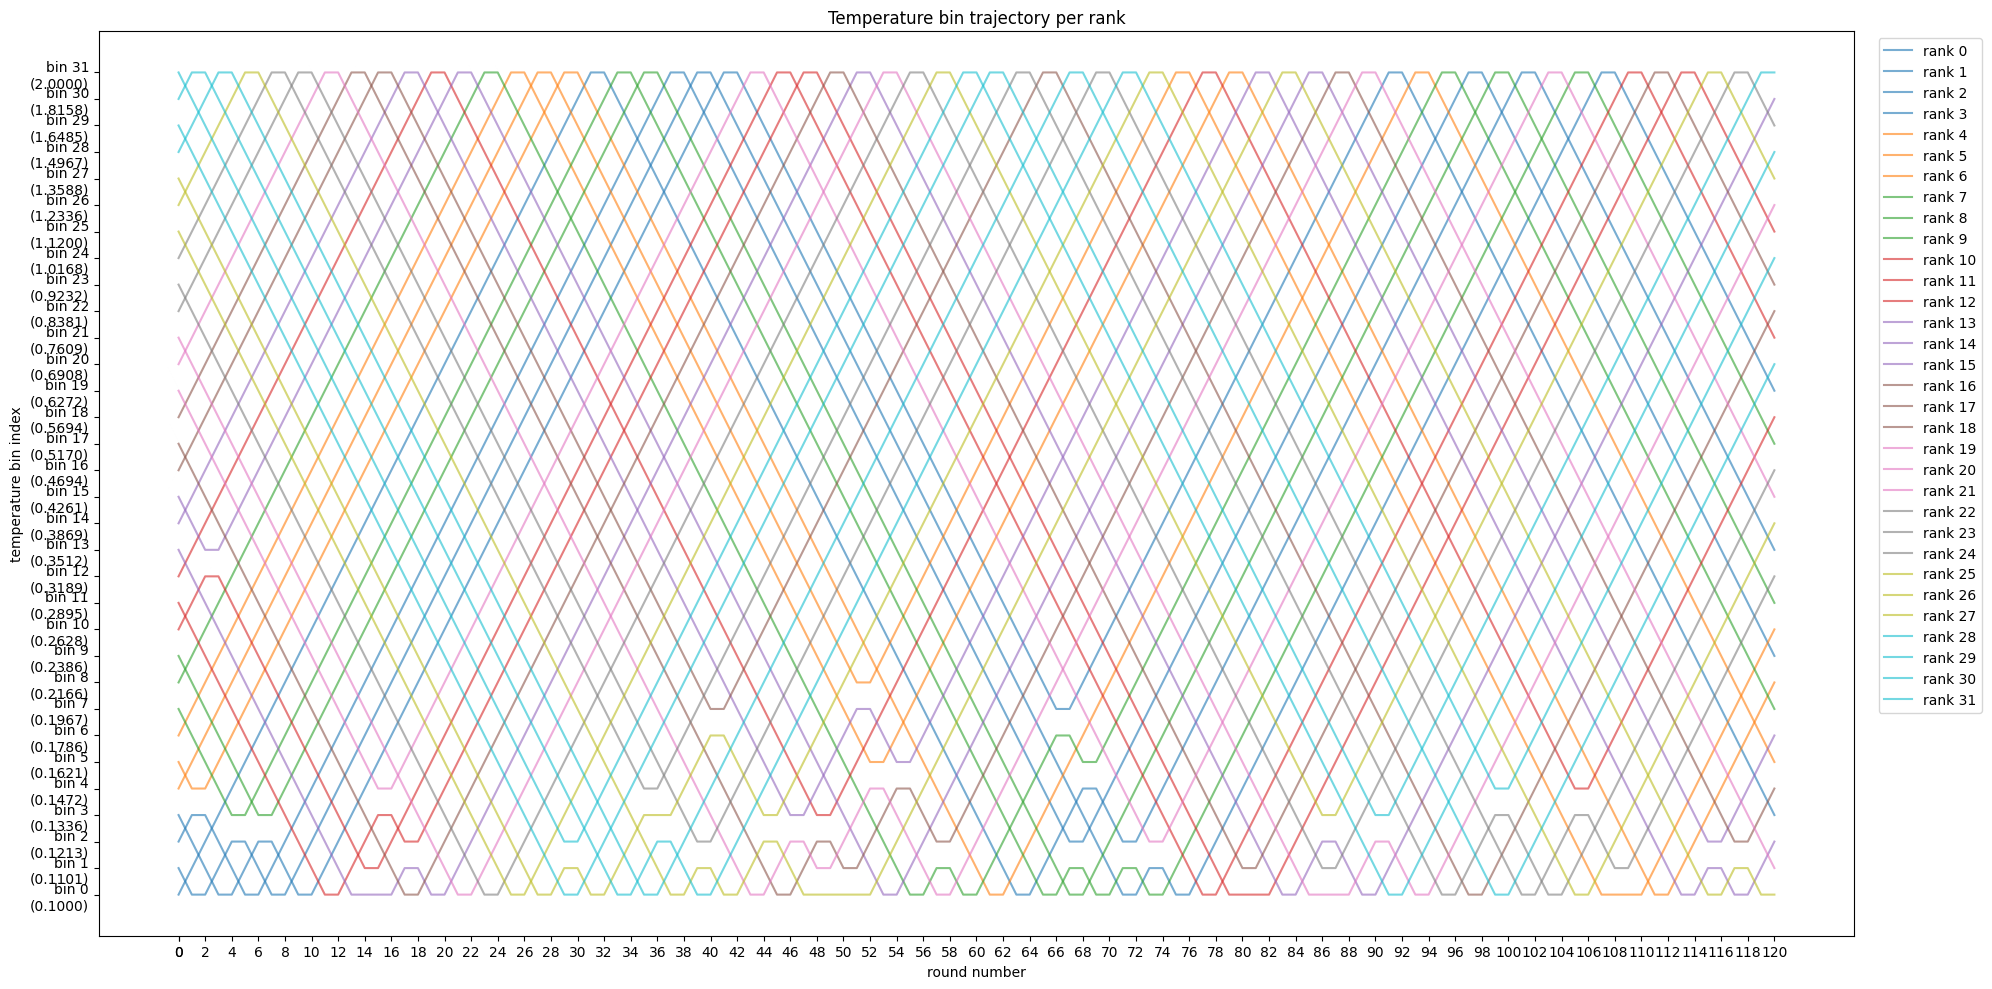

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))

cmap = plt.get_cmap('tab10', n_ranks)

for i in range(n_ranks):
    ax.plot(
        np.arange(n_rounds+1),
        traj[:, i],
        color=cmap(i),
        label=f'rank {i}',
        alpha=0.6,
    )

#tofu fix the tick number at the moment the count is change after round round nbr so the first change  is at the end of round 0
ax.set_xlabel('round number')
tick_positions = [0] + list(range(0, n_rounds+1, 2))
tick_labels = ['start'] + list(range(0, n_rounds+1, 2))
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)

ax.set_ylabel('temperature bin index')
ax.set_yticks(range(n_ranks))
ax.set_yticklabels([f'bin {j}\n({temps[j]:.4f})' for j in range(n_ranks)])
ax.set_title('Temperature bin trajectory per rank')
ax.legend(markerscale=4, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
fig.savefig("trajectory.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
def round_trip_stats(traj, n_rounds, n_ranks):
    for rank in range(n_ranks):
        path = traj[:, rank]
        
        # rounds to first reach top bin
        top_visits = np.where(path == n_ranks - 1)[0]
        rounds_to_top = top_visits[0] if len(top_visits) > 0 else None
        
        # round trips: top -> bottom -> top
        trips = 0
        trip_lengths = []
        at_top = False
        top_round = None
        
        for r in range(n_rounds + 1):
            if path[r] == n_ranks - 1 and not at_top:
                at_top = True
                top_round = r
            elif path[r] == 0 and at_top:
                at_top = False
                trips += 1
                trip_lengths.append(r - top_round)
                at_top = False
        
        top_str = f"{rounds_to_top}" if rounds_to_top is not None else "never"
        if trips > 0:
            print(f"Rank {rank:2d}: rounds to top bin: {top_str}, round trips: {trips}, avg {np.mean(trip_lengths):.1f} rounds per trip")
        else:
            print(f"Rank {rank:2d}: rounds to top bin: {top_str}, round trips: 0")

round_trip_stats(traj, n_rounds, n_ranks)

Rank  0: rounds to top bin: 31, round trips: 1, avg 32.0 rounds per trip
Rank  1: rounds to top bin: 39, round trips: 1, avg 32.0 rounds per trip
Rank  2: rounds to top bin: 37, round trips: 0
Rank  3: rounds to top bin: 41, round trips: 0
Rank  4: rounds to top bin: 27, round trips: 1, avg 80.0 rounds per trip
Rank  5: rounds to top bin: 29, round trips: 1, avg 32.0 rounds per trip
Rank  6: rounds to top bin: 25, round trips: 1, avg 86.0 rounds per trip
Rank  7: rounds to top bin: 33, round trips: 1, avg 32.0 rounds per trip
Rank  8: rounds to top bin: 23, round trips: 1, avg 32.0 rounds per trip
Rank  9: rounds to top bin: 35, round trips: 1, avg 32.0 rounds per trip
Rank 10: rounds to top bin: 45, round trips: 1, avg 32.0 rounds per trip
Rank 11: rounds to top bin: 47, round trips: 1, avg 32.0 rounds per trip
Rank 12: rounds to top bin: 19, round trips: 0
Rank 13: rounds to top bin: 51, round trips: 1, avg 32.0 rounds per trip
Rank 14: rounds to top bin: 17, round trips: 1, avg 96.0

In [15]:
energies = np.vstack(df_exp_stats['energy'].apply(lambda s: parse_space_string(s, dtype=float)).values)
energies[10] # energy after round 10 on each rank

array([-9.5490e+00, -8.9553e+00, -8.7959e+00, -8.9070e+00, -9.8566e+00,
       -9.6250e+00, -8.9813e+00, -9.5339e+00, -9.6000e-03, -9.0269e+00,
       -8.4178e+00, -8.8165e+00, -9.9000e-03, -5.2051e+00, -1.0900e-02,
       -8.4220e+00, -7.9000e-03, -8.1028e+00, -1.3200e-02, -8.5850e+00,
       -9.5000e-03, -5.4000e-03, -8.4000e-03, -8.2000e-03, -1.3400e-02,
       -1.4000e-02, -8.9000e-03, -6.2000e-03, -4.8000e-03, -1.2100e-02,
       -7.5000e-03, -5.3000e-03])

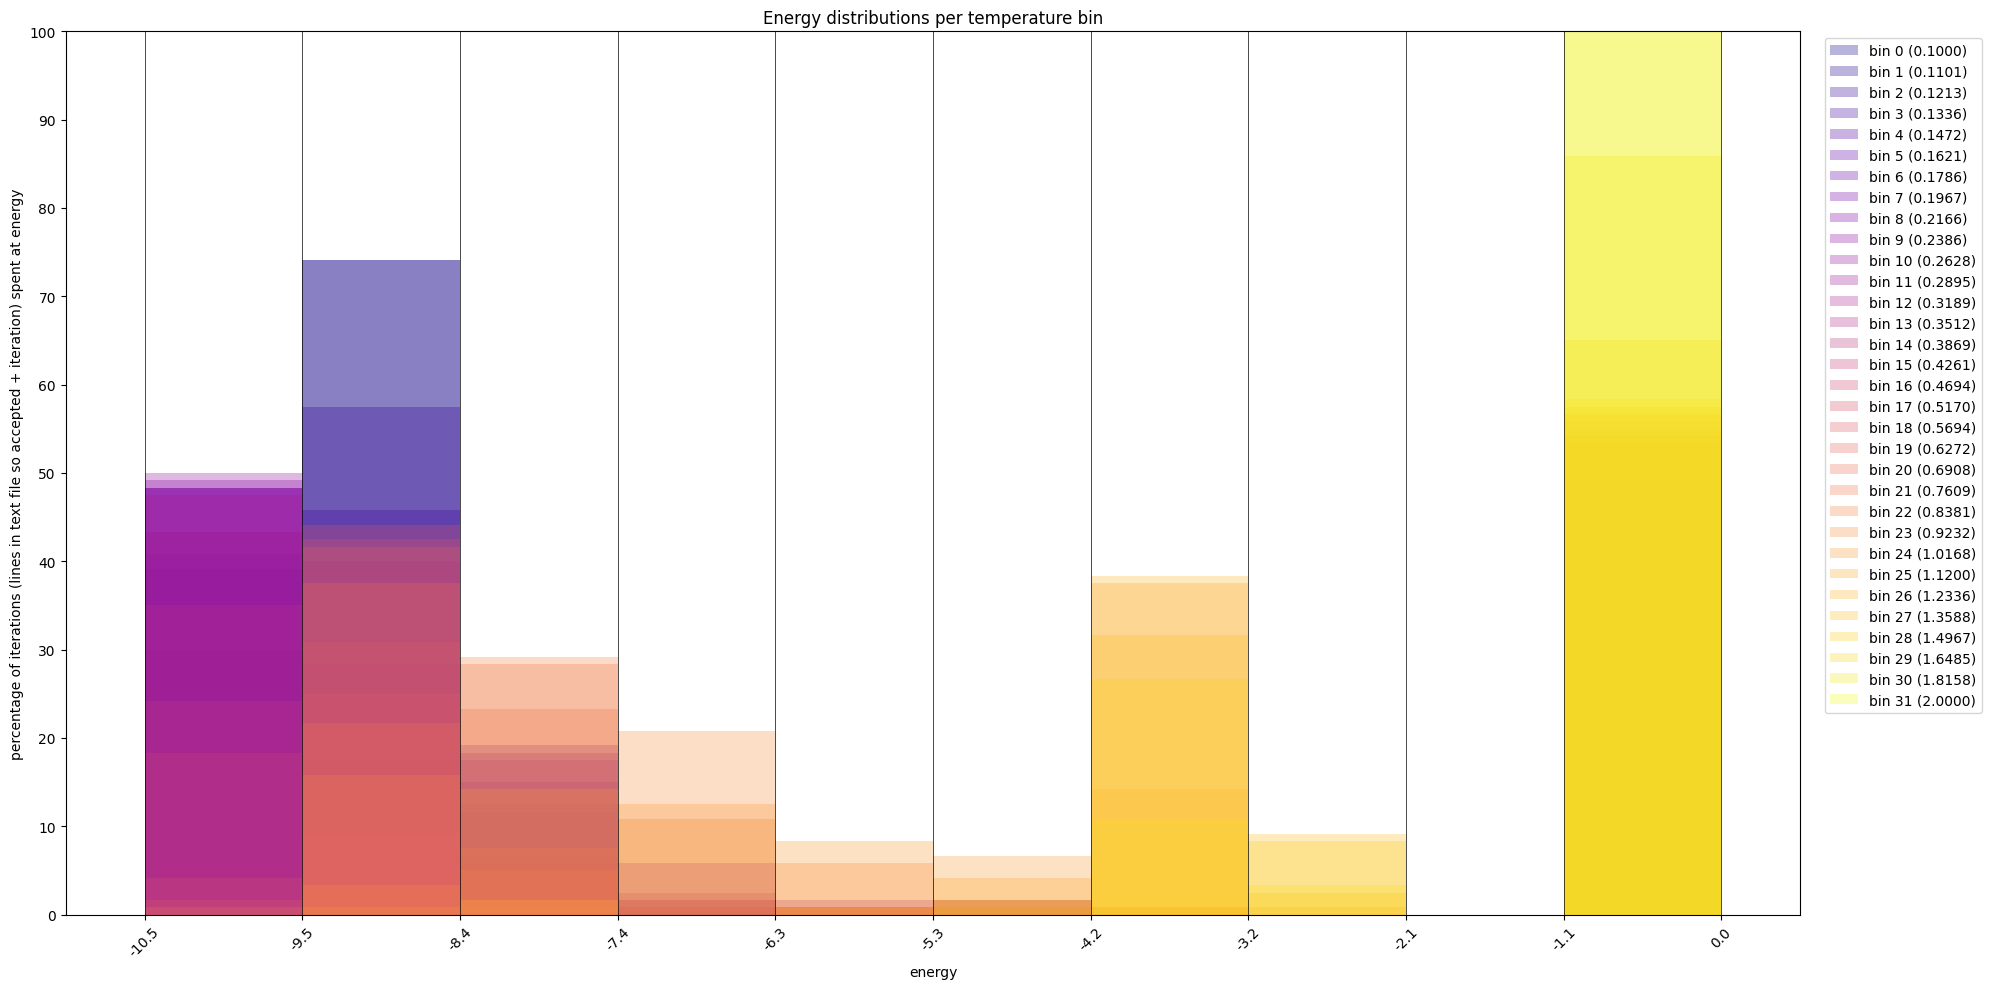

In [16]:
# for each bin, collect all energies sampled there across all rounds and ranks
n_bins = n_ranks
bin_energies = {b: [] for b in range(n_bins)}

for r in range(n_rounds):
    for i in range(n_ranks):
        b = traj[r, i]  # which bin rank i is at in round r
        bin_energies[b].append(energies[r, i])

#compute the energy bin sizes from the minimum energy value
n_bins_histogram = 10
E_min = min(e for energies in bin_energies.values() for e in energies)
E_max = 0.0  # flat region
bin_width = (E_max - E_min) / n_bins_histogram
bin_edges = np.linspace(E_min, E_max, n_bins_histogram + 1)

# plot
fig, ax = plt.subplots(figsize=(20, 10))

cmap = plt.get_cmap('plasma', n_bins)

for b in range(n_bins):
    ax.hist(
        bin_energies[b],
        bins=bin_edges,
        edgecolor='none',
        alpha=0.3,
        color=cmap(b),
        label=f'bin {b} ({temps[b]:.4f})',
        density=False,
        weights=np.ones(len(bin_energies[b])) / len(bin_energies[b]) * 100,
    )

# add vertical lines at each separation edge between bins
for edge in bin_edges:
    ax.axvline(x=edge, color='black', linewidth=0.5)

ax.set_xlabel('energy')
ax.set_xticks(bin_edges)
ax.set_xticklabels([f'{e:.1f}' for e in bin_edges], rotation=45)
#ax.set_yscale('log')
ax.set_yticks(range(0, 101, 10))
ax.set_ylim(0, 100)
ax.set_ylabel('percentage of iterations (lines in text file so accepted + iteration) spent at energy')
ax.set_title('Energy distributions per temperature bin')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
fig.savefig('energy_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

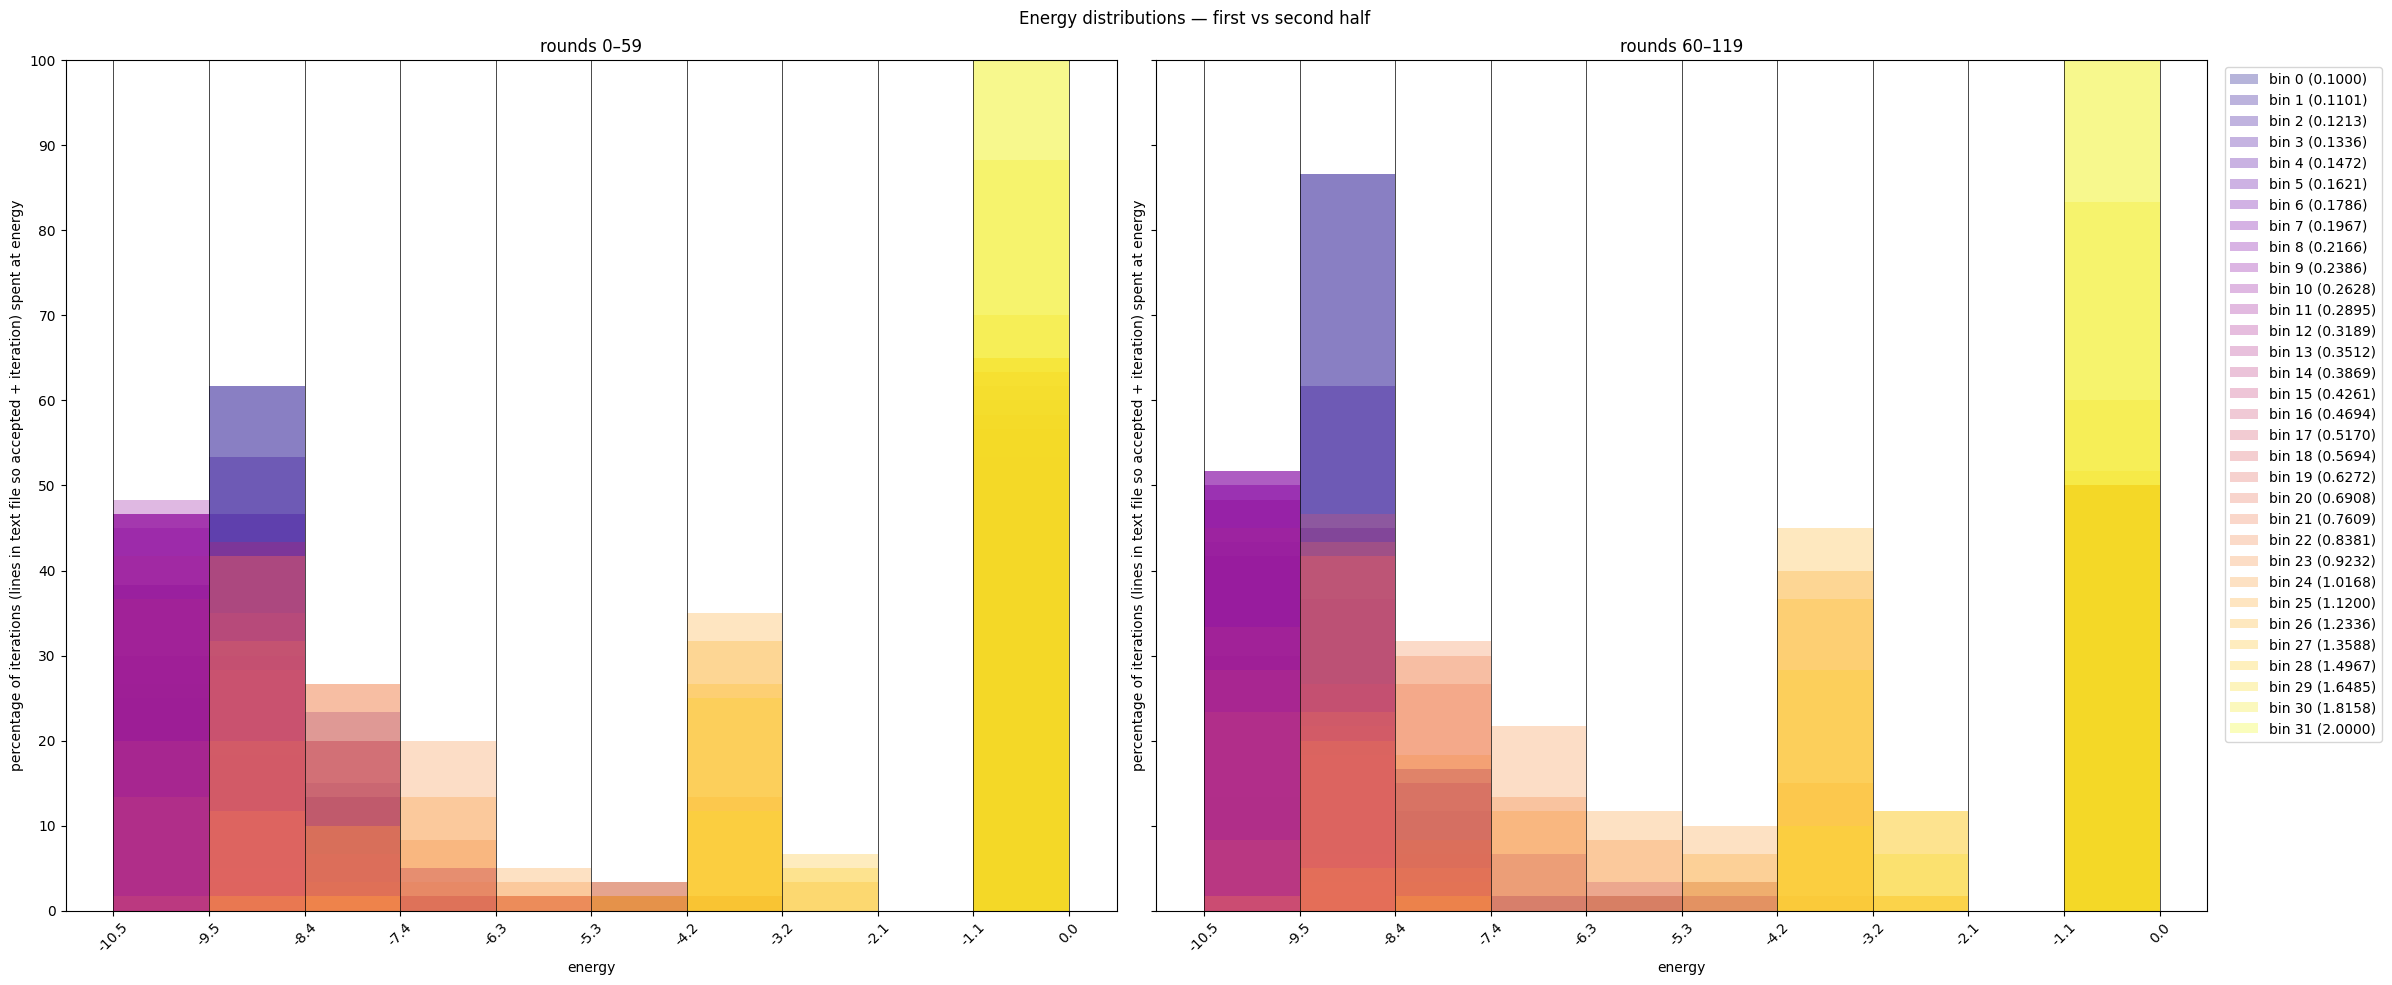

In [17]:
mid = n_rounds // 2

fig, axes = plt.subplots(1, 2, figsize=(24, 10), sharey=True)

for ax, (start, end), label in zip(
    axes,
    [(0, mid), (mid, n_rounds)],
    [f'rounds 0–{mid-1}', f'rounds {mid}–{n_rounds-1}']
):
    bin_energies = {b: [] for b in range(n_bins)}
    for r in range(start, end):
        for i in range(n_ranks):
            b = traj[r, i]
            bin_energies[b].append(energies[r, i])

    for b in range(n_bins):
        ax.hist(
            bin_energies[b],
            bins=bin_edges,
            alpha=0.3,
            edgecolor='none',
            linewidth=0,
            color=cmap(b),
            label=f'bin {b} ({temps[b]:.4f})',
            density=False,
            weights=np.ones(len(bin_energies[b])) / len(bin_energies[b]) * 100,
        )
    for edge in bin_edges:
        ax.axvline(x=edge, color='black', linewidth=0.5)

    ax.set_xticks(bin_edges)
    ax.set_xticklabels([f'{e:.1f}' for e in bin_edges], rotation=45)
    ax.set_xlabel('energy')
    ax.set_yticks(range(0, 101, 10))
    ax.set_ylim(0, 100)
    ax.set_ylabel('percentage of iterations (lines in text file so accepted + iteration) spent at energy')
    ax.set_title(label)
    
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.suptitle('Energy distributions — first vs second half')
plt.tight_layout()
fig.savefig('energy_distributions_halves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                             name
0                    _experiments
1                 sqlite_sequence
2         _experiments_all_curves
3                       _measures
4               _experiment_stats
5  _experiment_stats_intra_rounds


In [19]:
df_curves[::200].head(4)

,id,frameNumber,rankNumber,temp,energy,time_in_sequence
0,1,1,0,0.100000,0.00000,0.0
200,201,200,0,0.110146,-7.81226,9258.0
400,401,400,0,0.121321,-8.36201,22213.9
600,601,600,0,0.147189,-8.12884,34782.0


In [20]:
df_measures[::200].head(4)

,id,curveID,inputSphereRadius,V0,V,A0,A,C0,C,X0,X,L,edgeLength,numberOfBalls,radiusGyration,reachOfClosedComplement
0,1,1,1.31012,68.5429,68.5429,104.9545,104.9545,40.1773,40.1773,0.0,0.0000,12.75,0.25,51,None,None
200,201,201,1.31012,68.5429,65.7904,104.9545,91.8593,40.1773,36.1541,0.0,12.5664,12.75,0.25,51,None,None
400,401,401,1.31012,68.5429,65.5967,104.9545,90.8813,40.1773,35.9831,0.0,12.5664,12.75,0.25,51,None,None
600,601,601,1.31012,68.5429,65.6788,104.9545,90.8634,40.1773,35.8991,0.0,12.5664,12.75,0.25,51,None,None


In [21]:
df_curves.iloc[0]

id                  1.0
frameNumber         1.0
rankNumber          0.0
temp                0.1
energy              0.0
time_in_sequence    0.0
Name: 0, dtype: float64

In [22]:
df_exp_stats_intra_rounds.iloc[0]

id                   1.000000
curveID              1.000000
rank                 0.000000
it_no                0.000000
T                    0.100000
prob                 1.000000
deltaE               0.000000
accept               1.000000
energy               0.000000
bin_index            0.000000
time                 0.000306
round_nbr            0.000000
it_no_intra_round    0.000000
Name: 0, dtype: float64

In [23]:
df_exp_stats_intra_rounds.head(10)

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.1,1.000,0.00000,1,0.00000,0,0.000306,0,0
1,2,2,0,2020,0.1,0.998,0.00021,0,-0.00850,0,25.839197,0,2020
2,3,3,0,6063,0.1,1.062,-0.00604,0,-0.00732,0,79.904376,0,6063
3,4,4,0,7077,0.1,1.011,-0.00109,0,-0.01639,0,93.504922,0,7077
4,5,5,0,10120,0.1,0.956,0.00450,0,-0.00878,0,135.769553,0,10120
5,6,6,0,11137,0.1,0.996,0.00042,0,-0.00659,0,149.304890,0,11137
6,7,7,0,12151,0.1,1.006,-0.00058,0,-0.00862,0,162.415110,0,12151
7,8,8,0,13163,0.1,1.137,-0.01280,0,-0.01269,0,175.528196,0,13163
8,9,9,0,14173,0.1,1.015,-0.00145,0,-0.01202,0,189.048409,0,14173
9,10,10,0,15184,0.1,0.941,0.00612,0,-0.00855,0,202.658437,0,15184


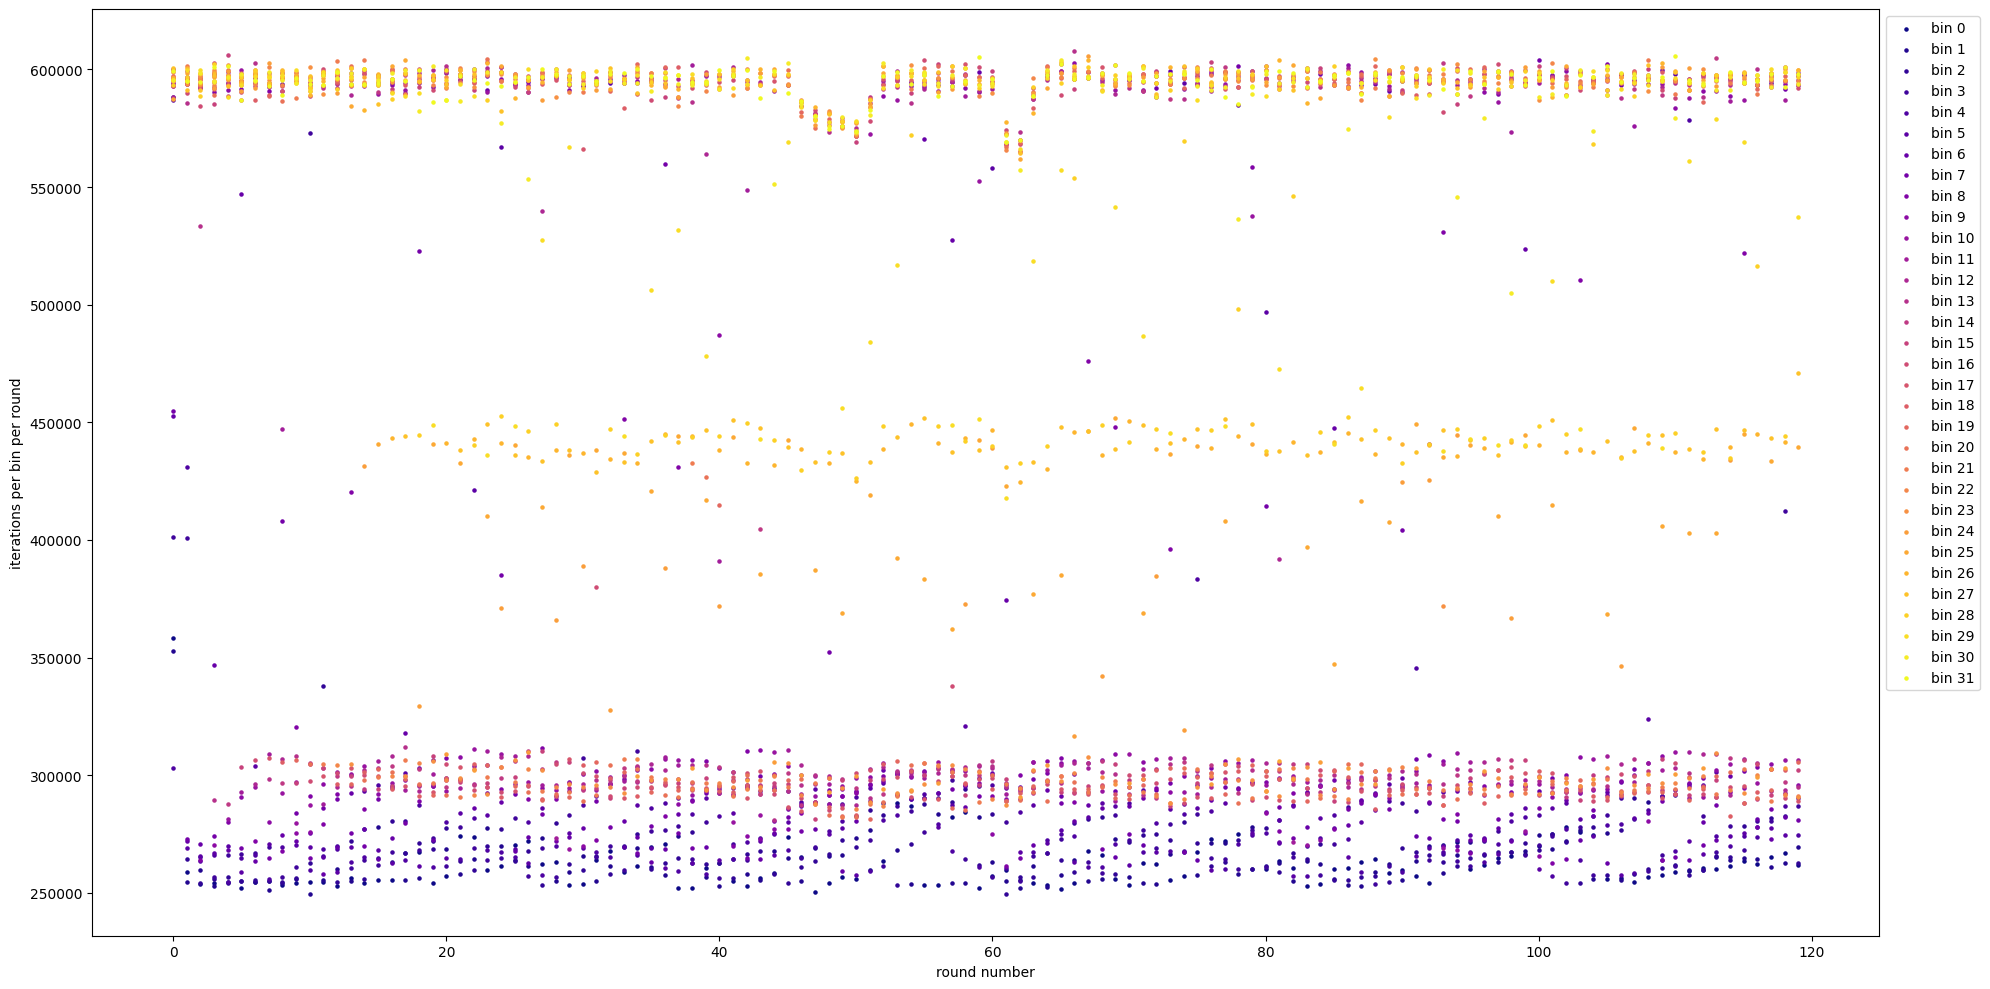

In [24]:
data_entries_generated_per_bin_round = (df_exp_stats_intra_rounds
    .groupby(['round_nbr', 'bin_index'])
    .size()
    .reset_index(name='n_iterations')
)

iterations_per_bin_round = (df_exp_stats_intra_rounds
    .groupby(['round_nbr', 'bin_index'])['it_no_intra_round']
    .max()
    .reset_index(name='max_iteration')
)


fig, ax = plt.subplots(figsize=(20, 10))
cmap = plt.get_cmap('plasma', size)
for b in range(size):
    data = iterations_per_bin_round[iterations_per_bin_round['bin_index'] == b]
    ax.scatter(data['round_nbr'], data['max_iteration'], s=5, color=cmap(b), label=f'bin {b}')
    #data = data_entries_generated_per_bin_round[data_entries_generated_per_bin_round['bin_index'] == b]
    #ax.scatter(data['round_nbr'], data['n_iterations'], s=5, color=cmap(b), label=f'bin {b}')

ax.set_xlabel('round number')
ax.set_ylabel('iterations per bin per round')
ax.legend(bbox_to_anchor=(1.0, 1), loc='upper left')
plt.tight_layout()
fig.savefig(f'number_iterations_per_round.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
curve_to_round = df_exp_stats_intra_rounds.drop_duplicates('curveID').set_index('curveID')['round_nbr']
df_curves['round_nbr'] = df_curves['id'].map(curve_to_round)

In [26]:
def assign_bin_index(T, dic_temps):
    for ind, t in dic_temps.items():
        if abs(T - t) < 0.0001:
            return ind
    return None

df_curves['bin_index'] = df_curves['temp'].apply(
    lambda t: assign_bin_index(t, dic_temps)
)
# check
print(df_curves[['id', 'rankNumber', 'time_in_sequence', 'round_nbr', 'bin_index', 'temp']].head(5).to_string())
print(f"\nUnassigned rows: {df_curves['bin_index'].isna().sum()}")

   id  rankNumber  time_in_sequence  round_nbr  bin_index  temp
0   1           0               0.0          0          0   0.1
1   2           0              25.8          0          0   0.1
2   3           0              79.9          0          0   0.1
3   4           0              93.5          0          0   0.1
4   5           0             135.8          0          0   0.1

Unassigned rows: 0


Now I want to plot energy distributions over the even rounds between $T_{i}$ and $T_{i+1}$ on the same graph, the probability of acceptance of that round is the title of the graph.

There are $n-1$ edges, so $\lfloor \frac{n-1}{2} \rfloor$ edges transitioning on even rounds and $n-1 - \lfloor \frac{n-1}{2} \rfloor$ on odd rounds.


In [27]:
even_rounds = df_curves[df_curves['round_nbr'] % 2 == 0]
even_rounds_intra = df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['round_nbr'] % 2 == 0]
X = 50
last_X = (even_rounds_intra
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

In [28]:
#last_X.groupby('bin_index')['energy'].count()

In [29]:
def avg_transition_prob(df_exp_stats, b, even=True, from_round=0):
    parity = 0 if even else 1
    rows = df_exp_stats[
        (df_exp_stats['round_nbr'] % 2 == parity) &
        (df_exp_stats['round_nbr'] >= from_round)
    ]
    probs = np.vstack(rows['prob'].apply(lambda s: parse_space_string(s, dtype=float)).values)
    bin_indices = np.vstack(rows['binIndices'].apply(parse_space_string).values)
    
    edge_probs = []
    for r in range(len(rows)):
        rank_at_b = np.where(bin_indices[r] == b)[0]
        if len(rank_at_b) > 0:
            edge_probs.append(probs[r, rank_at_b[0]])
    
    return round(np.mean(edge_probs), 3) if edge_probs else float('nan')

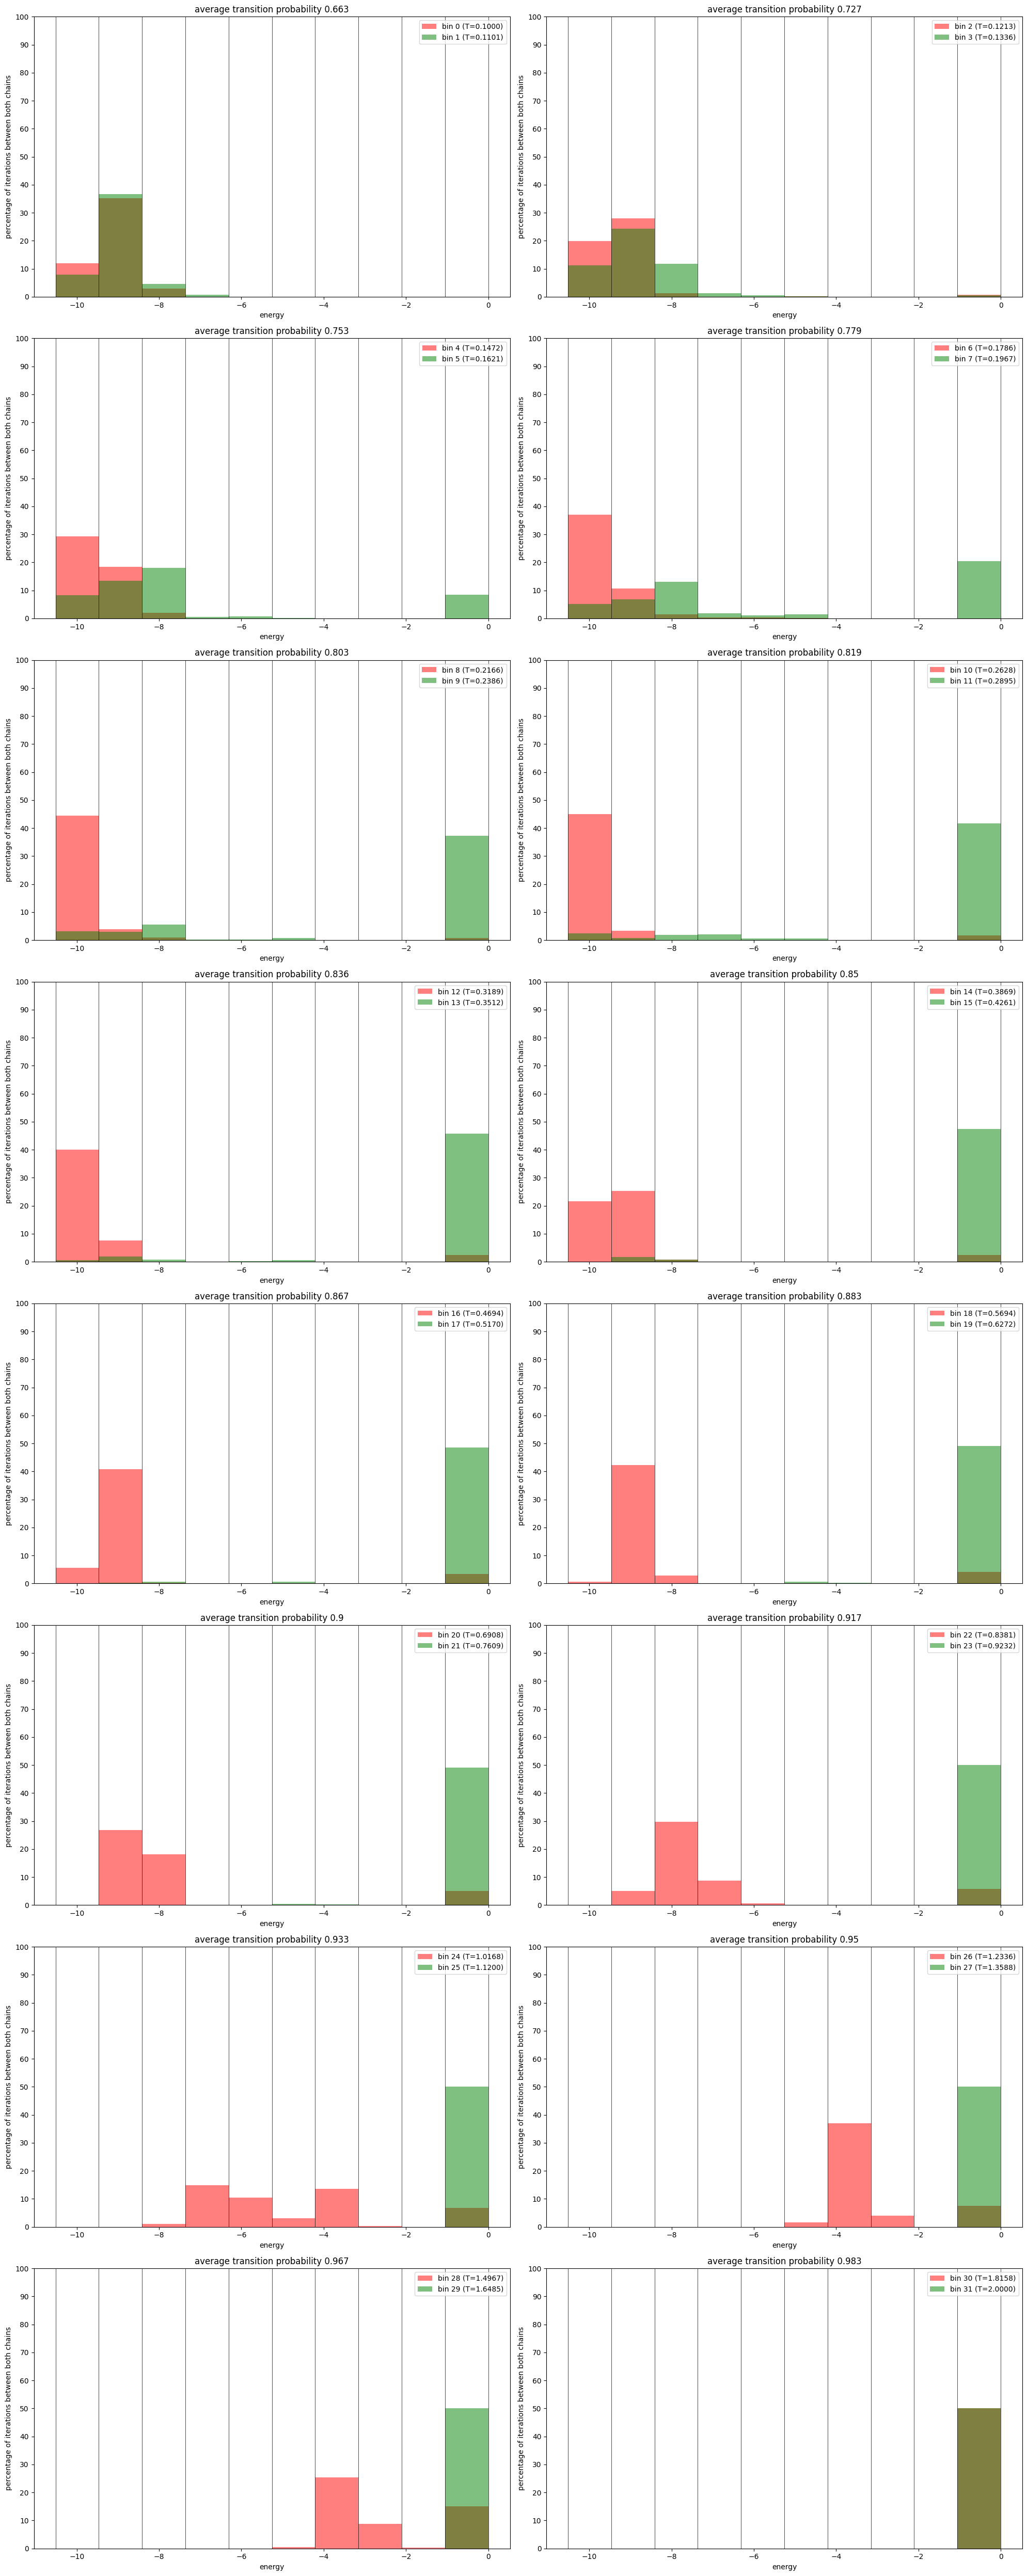

In [30]:

n_even_bins = size // 2  # 16 pairs
ncols = 2
nrows = n_even_bins // ncols  
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 50))

plot_idx = 0
for b in range(size):
    if b%2==0:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]

        data_b = last_X[last_X['bin_index'] == b]['energy']
        data_b1 = last_X[last_X['bin_index'] == b + 1]['energy']
        #data_b = even_rounds[even_rounds['bin_index'] == b]['energy']
        #data_b1 = even_rounds[even_rounds['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b)}')
        axes[row][col].legend()
        plot_idx+=1

plt.tight_layout()
fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
#last_X.groupby('bin_index')['energy'].count()

Now let's repeat the above graphs for values of round number after round $60$.

In [32]:
even_rounds_second_half = df_curves[(df_curves['round_nbr'] % 2 == 0 ) & (df_curves['round_nbr'] > number_of_rounds // 2 )]
even_rounds_intra_second_half = df_exp_stats_intra_rounds[(df_exp_stats_intra_rounds['round_nbr'] % 2 == 0) & (df_exp_stats_intra_rounds['round_nbr'] > number_of_rounds // 2)]
X = 50
last_X_second_half = (even_rounds_intra_second_half
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

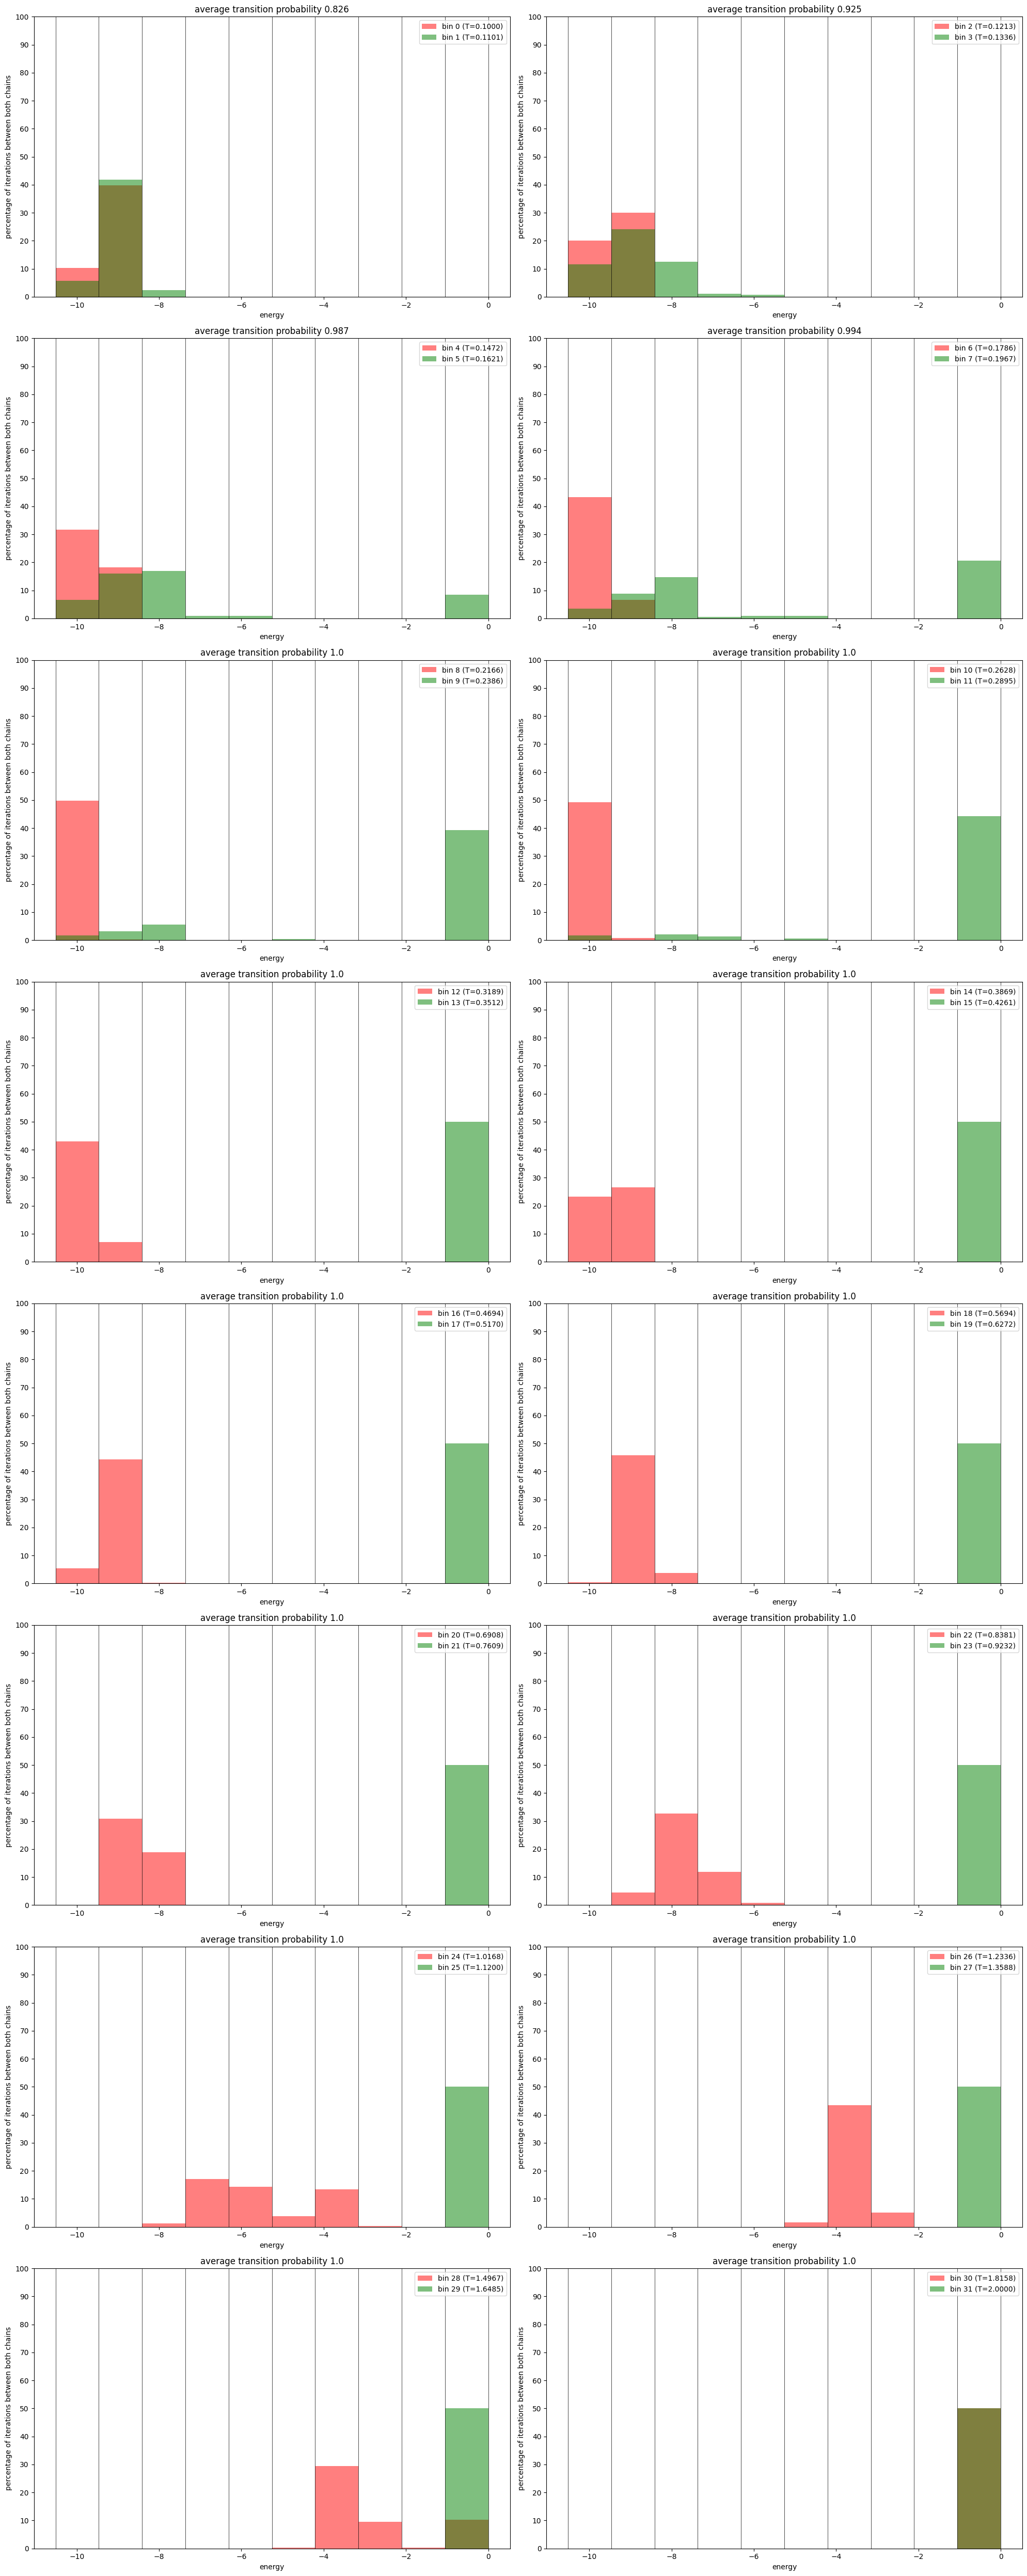

In [33]:

n_even_bins = size // 2  # 16 pairs
ncols = 2
nrows = n_even_bins // ncols  
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 50))

plot_idx = 0
for b in range(size):
    if b%2==0:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]

        #data_b = even_rounds_second_half[even_rounds_second_half['bin_index'] == b]['energy']
        #data_b1 = even_rounds_second_half[even_rounds_second_half['bin_index'] == b + 1]['energy']
        data_b = last_X_second_half[last_X_second_half['bin_index'] == b]['energy']
        data_b1 = last_X_second_half[last_X_second_half['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b, from_round=number_of_rounds // 2)}')
        axes[row][col].legend()
        plot_idx+=1

plt.tight_layout()
fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds_second_half.png', dpi=150, bbox_inches='tight')
plt.show()


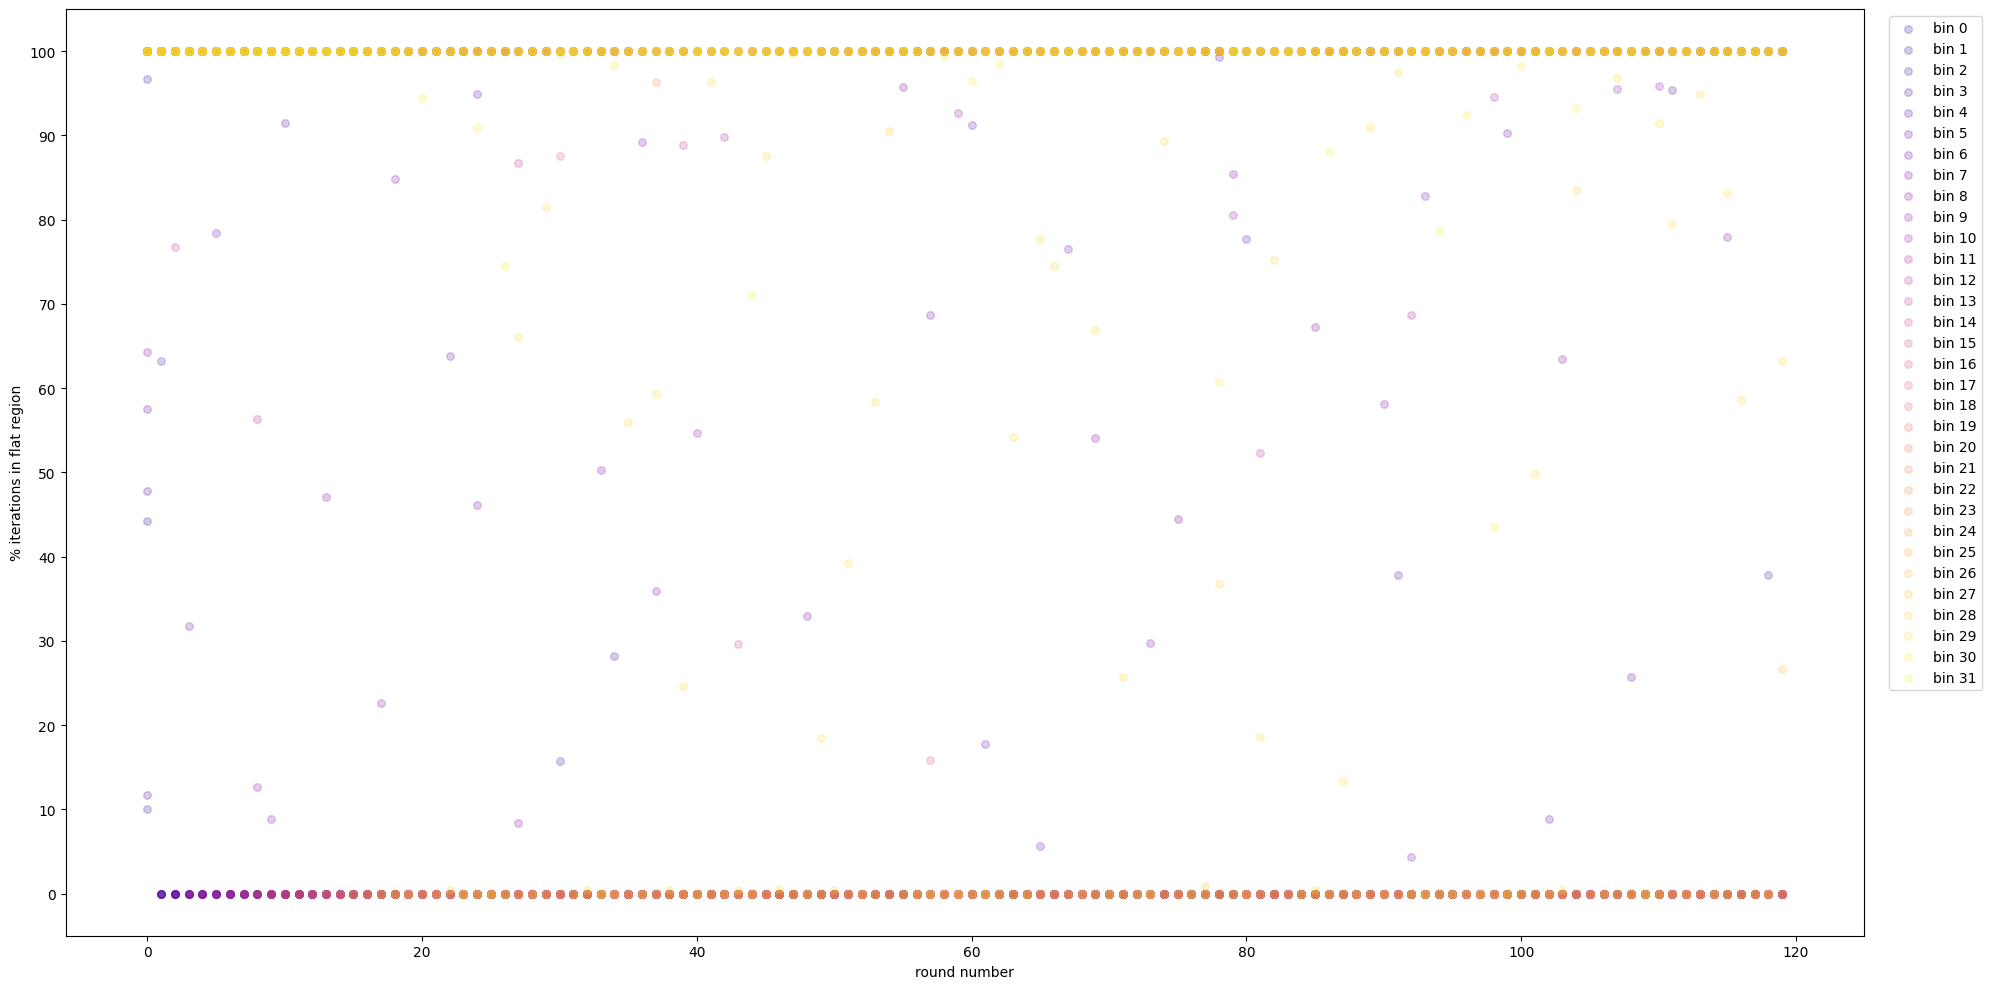

In [34]:
flat_region_threshold = bin_edges[-2]  # -1.0517

flat_fraction = (df_exp_stats_intra_rounds
    .groupby(['round_nbr', 'bin_index'])
    .apply(lambda g: (g['energy'] >= flat_region_threshold).sum() / len(g), include_groups=False)
    .reset_index(name='flat_fraction')
)

fig, ax = plt.subplots(figsize=(20, 10))
cmap = plt.get_cmap('plasma', size)
for b in range(size):
    data = flat_fraction[flat_fraction['bin_index'] == b]
    ax.scatter(data['round_nbr'], data['flat_fraction'] * 100, s=30, alpha = 0.2, color=cmap(b), label=f'bin {b}')

ax.set_xlabel('round number')
ax.set_ylabel('% iterations in flat region')
ax.set_yticks(range(0, 101, 10))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
fig.savefig(f'proportion_of_iterations_spent_in_coldest_bin.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
parse_space_string(df_exp_stats['prob'].iloc[1], dtype=float)

array([1.   , 0.   , 0.674, 0.   , 1.   , 0.   , 1.   , 0.   , 1.   ,
       0.   , 1.   , 0.   , 0.998, 0.   , 1.   , 0.   , 0.999, 0.   ,
       1.   , 0.   , 1.   , 0.   , 1.   , 0.   , 1.   , 0.   , 1.   ,
       0.   , 1.   , 0.   , 1.   , 0.   ])

In [36]:
df_exp_stats[:3:]

,id,experimentID,round_nbr,temperatures,prob,acceptOrNot,binIndices,energy
0,1,1,0,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,1.0 0.0 0.175 0.0 1.0 0.0 0.987 0.0 1.0 0.0 1....,1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 ...,1 0 3 2 5 4 7 6 9 8 11 10 13 12 15 14 17 16 19...,-7.64 -7.3447 -5.1964 -7.4936 -7.9358 -0.0061 ...
1,2,1,1,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,1.0 0.0 0.674 0.0 1.0 0.0 1.0 0.0 1.0 0.0 1.0 ...,1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 ...,2 0 3 1 6 4 8 5 10 7 12 9 14 11 16 13 18 15 20...,-8.2355 -8.0908 -6.8629 -7.9981 -8.2304 -7.434...
2,3,1,2,0.1 0.110146 0.121321 0.133631 0.147189 0.1621...,1.0 1.0 0.674 0.0 1.0 0.755 1.0 0.0 0.999 0.0 ...,1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 ...,3 1 2 0 7 5 9 4 11 6 12 8 15 10 17 13 19 14 21...,-8.1807 -8.2593 -7.9217 -8.1876 -8.4456 -8.027...


In [37]:
def prob_Ti_Ti_plus_1(prob_ordered_by_rank, bin_indices):
    sorted_by_bin_indices = np.zeros(len(prob_ordered_by_rank))
    for i in range(len(sorted_by_bin_indices)):
        sorted_by_bin_indices[i] = prob_ordered_by_rank[np.where(bin_indices == i)]
    return sorted_by_bin_indices

In [38]:
#check
prob_ordered_by_rank = parse_space_string(df_exp_stats['prob'].iloc[1], dtype=float)
bin_indices_ = parse_space_string(df_exp_stats['binIndices'].iloc[1])
print(prob_ordered_by_rank, bin_indices_)
prob_Ti_Ti_plus_1(prob_ordered_by_rank,bin_indices_)

[1.    0.    0.674 0.    1.    0.    1.    0.    1.    0.    1.    0.
 0.998 0.    1.    0.    0.999 0.    1.    0.    1.    0.    1.    0.
 1.    0.    1.    0.    1.    0.    1.    0.   ] [ 2  0  3  1  6  4  8  5 10  7 12  9 14 11 16 13 18 15 20 17 22 19 24 21
 26 23 28 25 30 27 31 29]


array([0.   , 0.   , 1.   , 0.674, 0.   , 0.   , 1.   , 0.   , 1.   ,
       0.   , 1.   , 0.   , 1.   , 0.   , 0.998, 0.   , 1.   , 0.   ,
       0.999, 0.   , 1.   , 0.   , 1.   , 0.   , 1.   , 0.   , 1.   ,
       0.   , 1.   , 0.   , 1.   , 1.   ])

In [39]:
# parse prob into a 2D array, shape (n_rounds, n_ranks)
#You're right to question it — .values converts the pandas Series to a numpy array before passing to np.vstack. But since np.vstack can handle a Series directly you don't need it.
probs_by_rank = np.vstack(df_exp_stats['prob'].apply(parse_space_string, dtype=float).values)
traj = np.vstack(df_exp_stats['binIndices'].apply(parse_space_string).values)  # shape (n_rounds, n_ranks)

probs_by_bin = np.vstack([
    prob_Ti_Ti_plus_1(probs_by_rank[r], traj[r]) 
    for r in range(n_rounds)
])


In [40]:
even_round_true_or_false = df_exp_stats['round_nbr'] % 2 == 0

In [41]:
even_round_true_or_false[5]

False

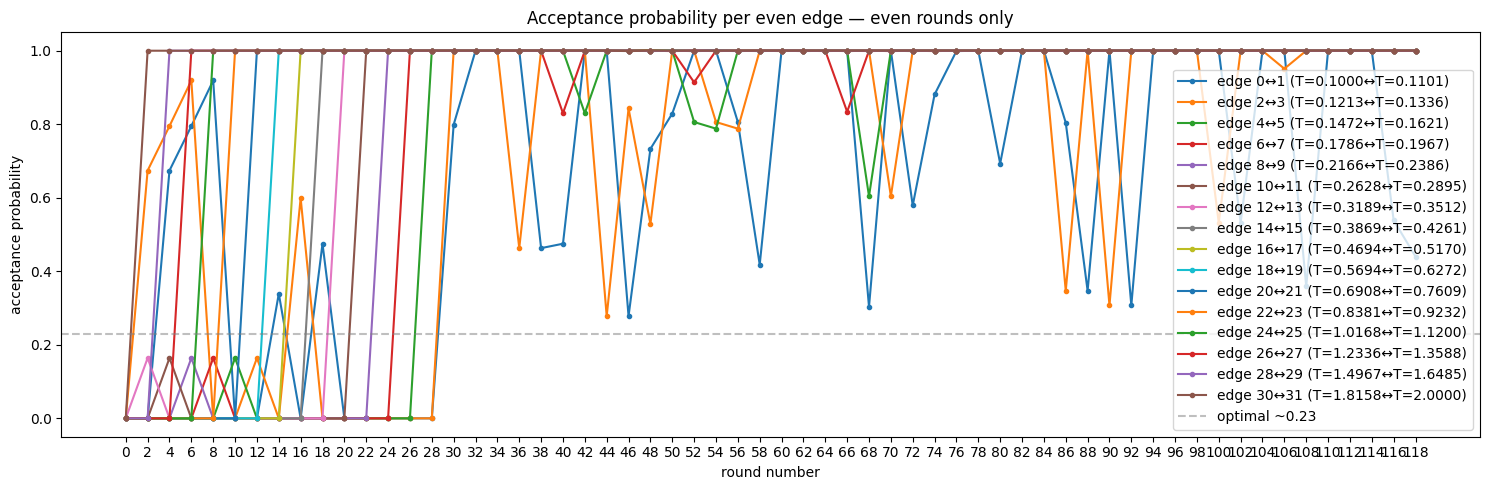

In [42]:
fig, ax = plt.subplots(figsize=(15, 5))

for b in range(0, n_bins - 1, 2):
    ax.plot(
        df_exp_stats.loc[even_round_true_or_false, 'round_nbr'],
        probs_by_bin[even_round_true_or_false, b],
        label=f'edge {b}↔{b+1} (T={temps[b]:.4f}↔T={temps[b+1]:.4f})',
        marker='o', markersize=3
    )

ax.set_xlabel('round number')
ax.set_xticks(df_exp_stats.loc[even_round_true_or_false, 'round_nbr'])
ax.set_ylabel('acceptance probability')
ax.set_title('Acceptance probability per even edge — even rounds only')
ax.axhline(0.23, color='gray', linestyle='--', alpha=0.5, label='optimal ~0.23')
ax.legend()

plt.tight_layout()
fig.savefig('acceptance_prob_even_edges_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
print(parse_space_string(df_exp_stats['prob'].iloc[22], dtype=float))
print(parse_space_string(df_exp_stats['acceptOrNot'].iloc[22], dtype=float))

[1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    0.996 1.    1.    1.    1.    1.    1.    1.    1.    1.    0.
 1.    0.    1.    0.    1.    0.    1.    0.   ]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 0. 1. 0. 1. 0. 1. 0.]


In [44]:
odd_rounds = df_curves[df_curves['round_nbr'] % 2 == 1]
odd_rounds_intra = df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['round_nbr'] % 2 == 1]
X = 50
last_X = (odd_rounds_intra
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

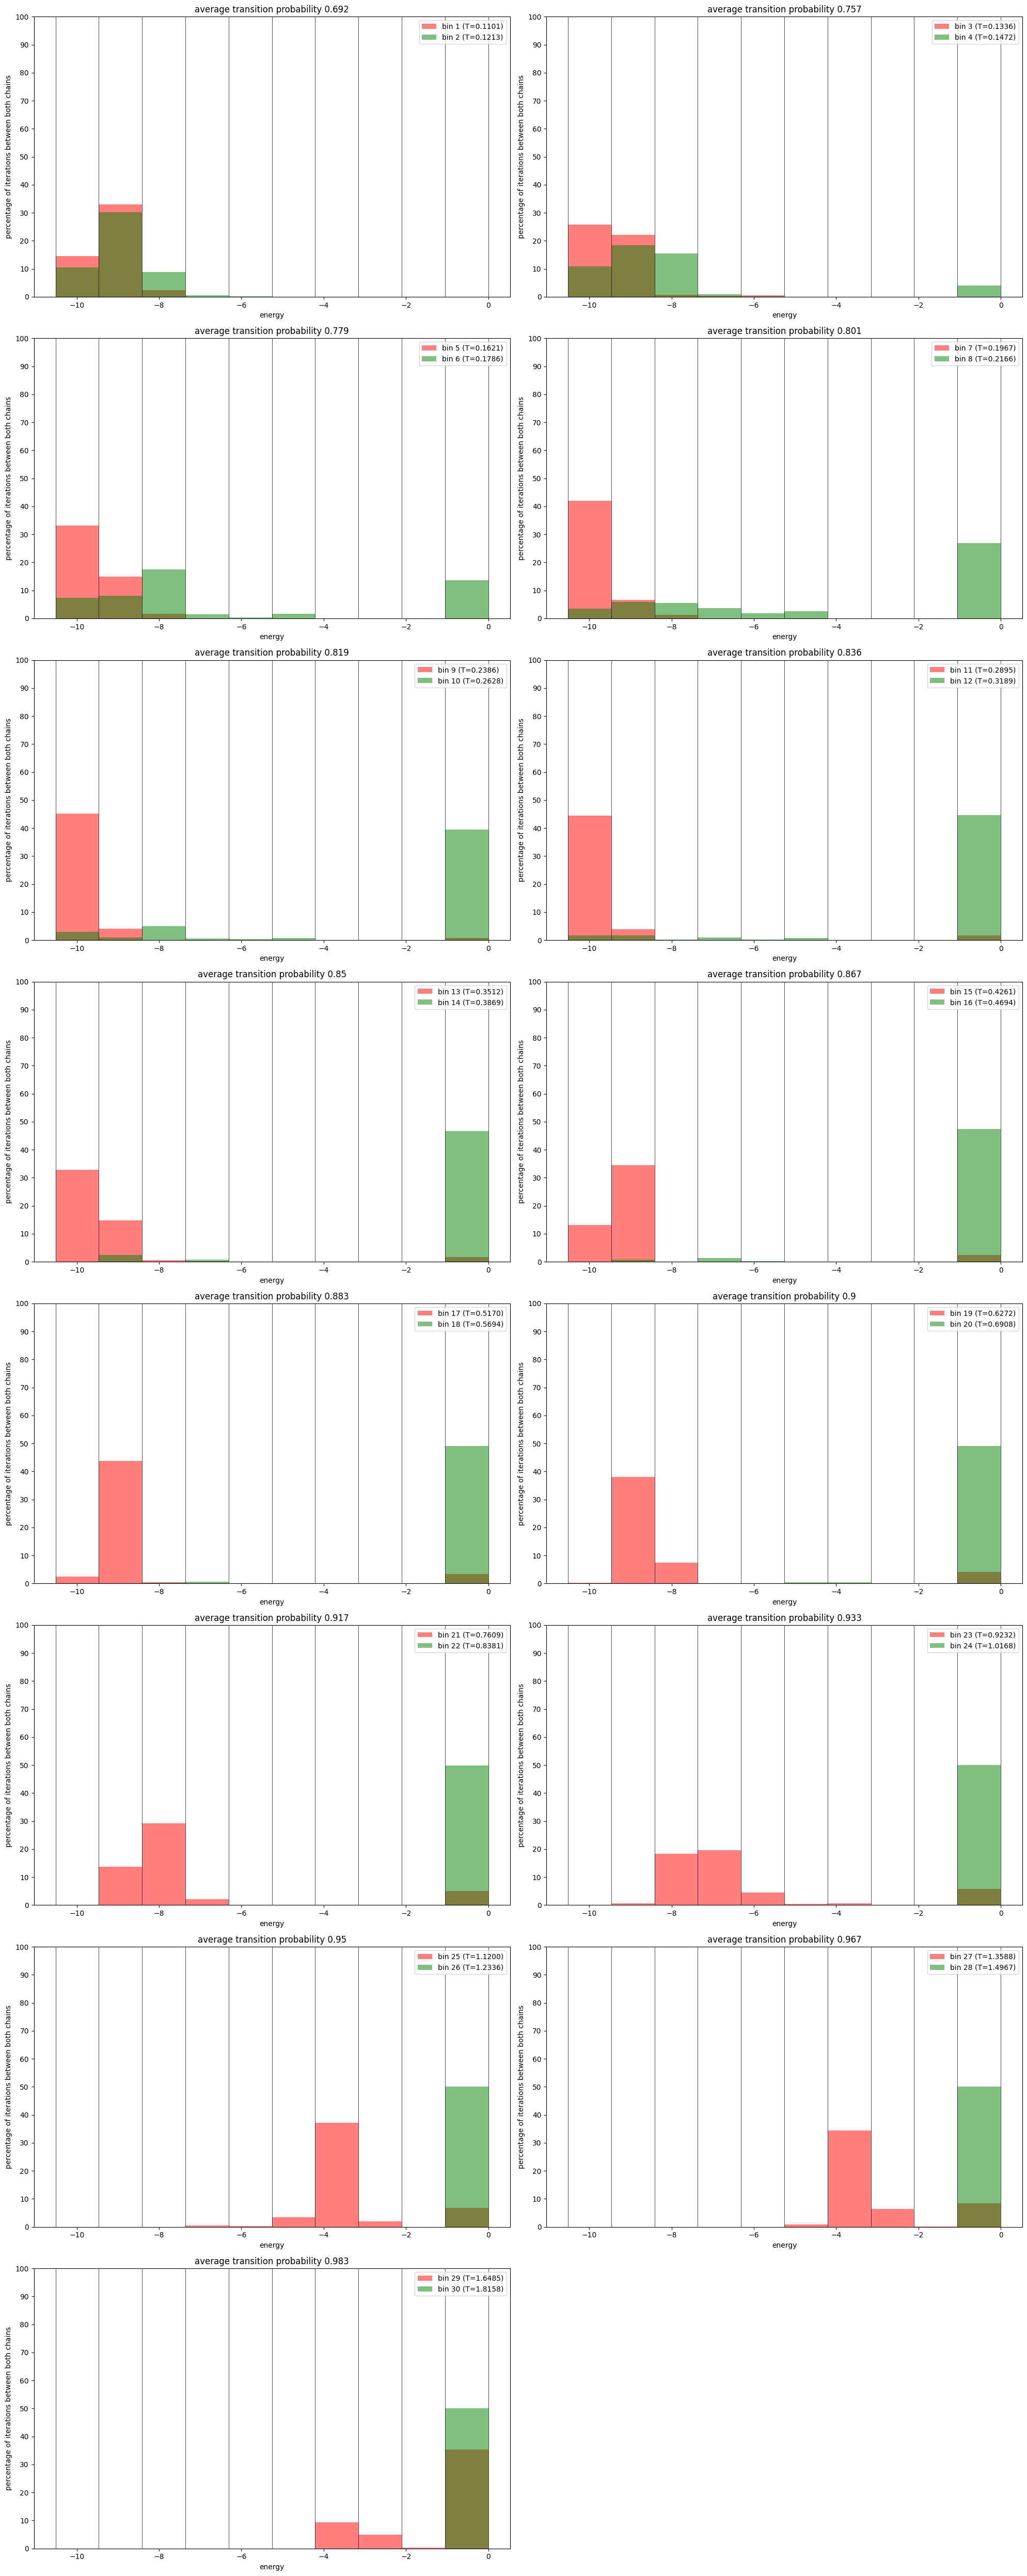

In [45]:
n_odd_bins = size // 2  # 16 pairs
ncols = 2
nrows = n_odd_bins // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 50))

plot_idx = 0
for b in range(size):
    if b%2==1:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]
        if b + 1 > size - 1:
            axes[-1][-1].set_visible(False)
            break
            
        data_b = last_X[last_X['bin_index'] == b]['energy']
        data_b1 = last_X[last_X['bin_index'] == b + 1]['energy']
        #data_b = odd_rounds[even_rounds['bin_index'] == b]['energy']
        #data_b1 = odd_rounds[even_rounds['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b, even=False)}')
        axes[row][col].legend()
        plot_idx+=1

plt.tight_layout()
fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
odd_rounds_second_half = df_curves[(df_curves['round_nbr'] % 2 == 1 ) & (df_curves['round_nbr'] > number_of_rounds // 2 )]
odd_rounds_intra_second_half = df_exp_stats_intra_rounds[(df_exp_stats_intra_rounds['round_nbr'] % 2 == 1) & (df_exp_stats_intra_rounds['round_nbr'] > number_of_rounds // 2)]
X = 50
last_X_second_half = (odd_rounds_intra_second_half
    .groupby(['round_nbr', 'rank'])
    .apply(lambda g: g.nlargest(X, 'it_no_intra_round'), include_groups=False)
    .reset_index(drop=True)
)

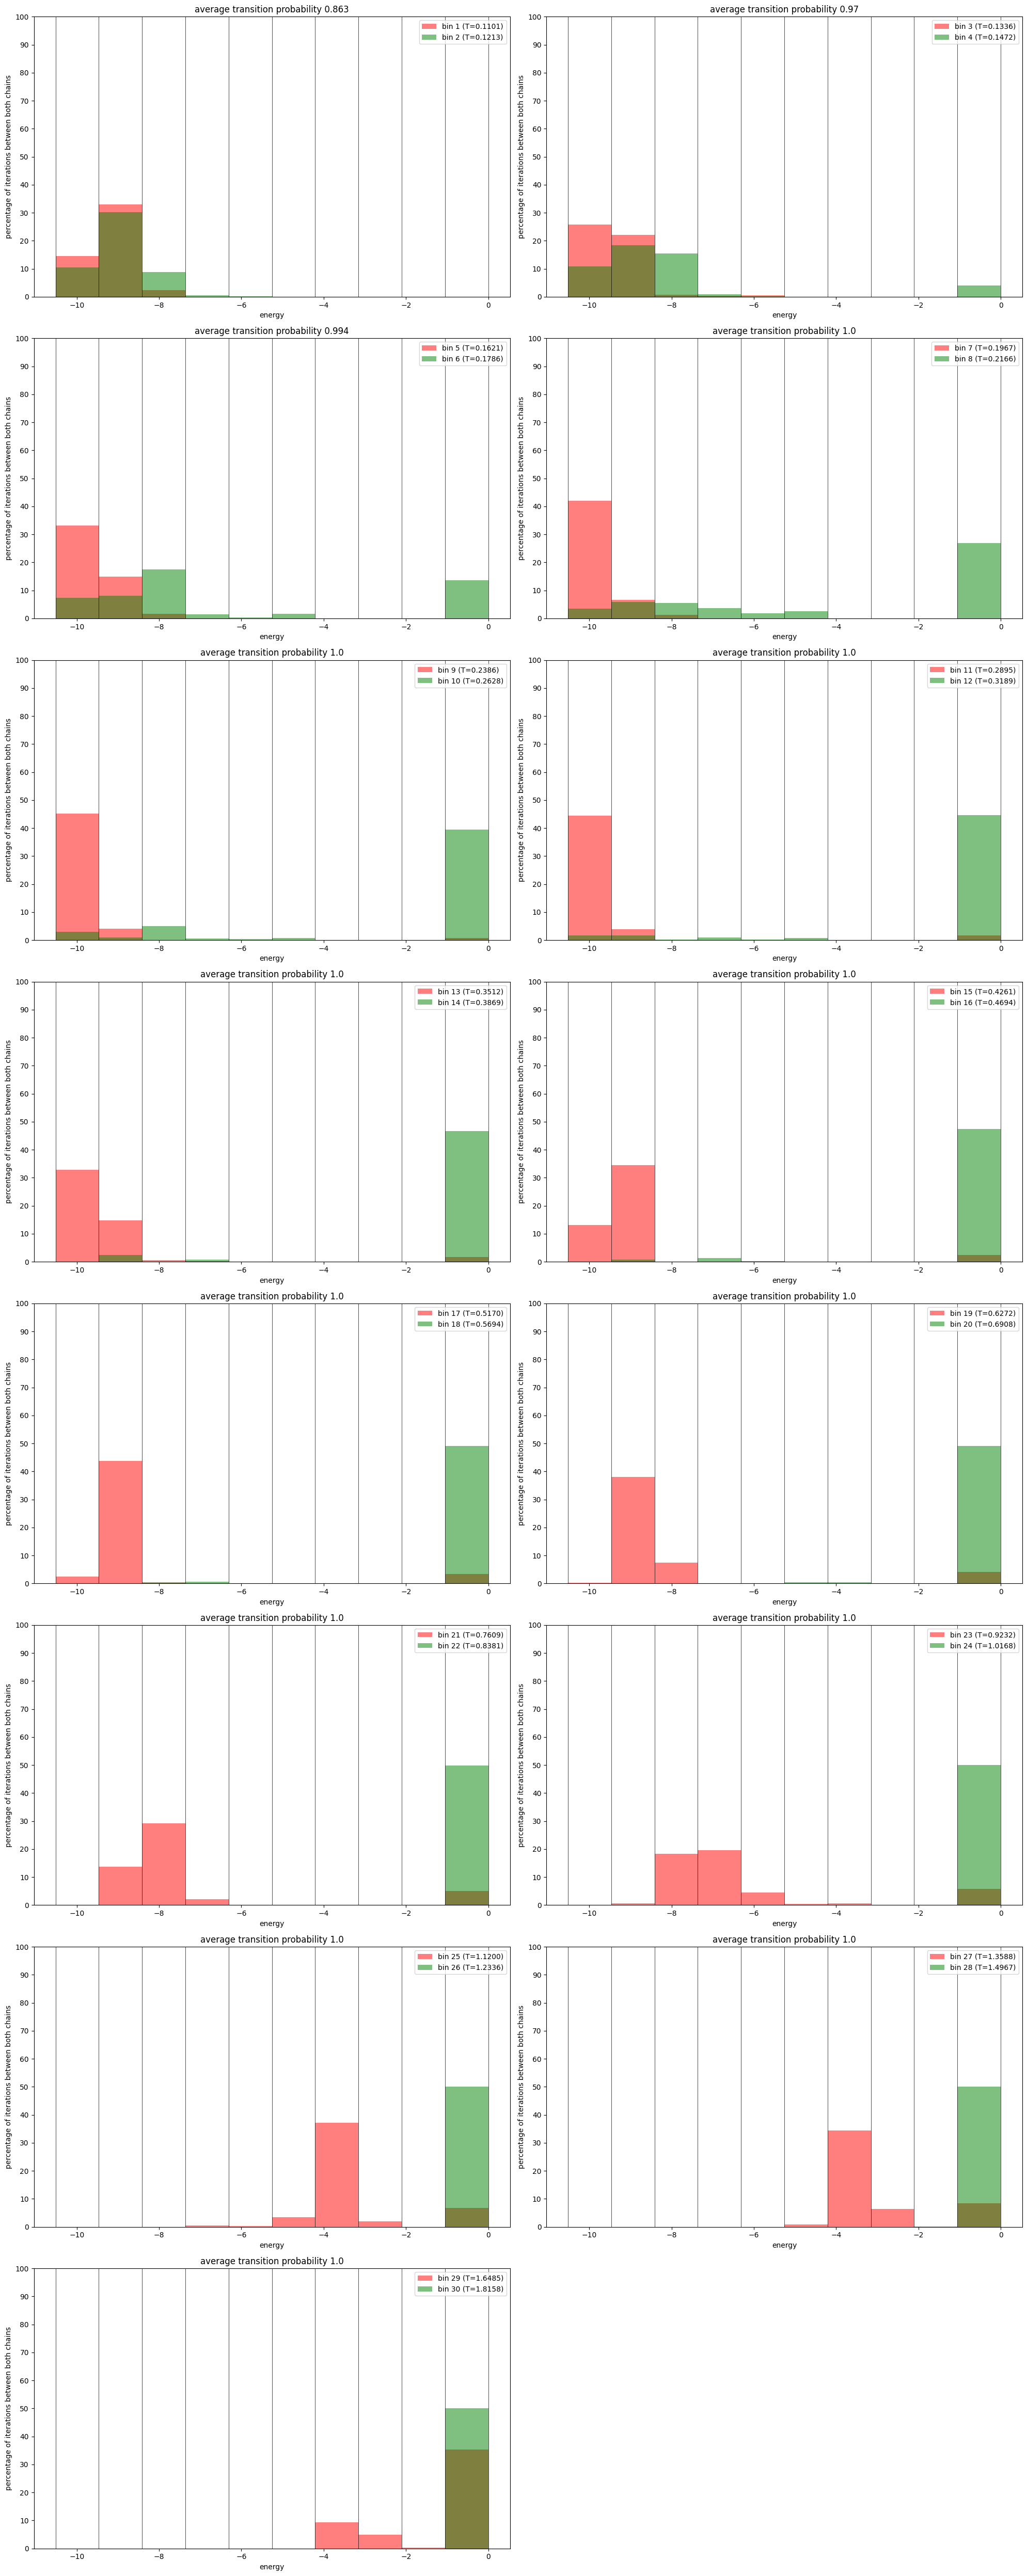

In [47]:
n_odd_bins = size // 2  # 16 pairs
ncols = 2
nrows = n_odd_bins // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 50))

plot_idx = 0
for b in range(size):
    if b%2==1:
        row = plot_idx // 2
        col = plot_idx % 2
        ax = axes[row][col]
        if b + 1 > size - 1:
            axes[-1][-1].set_visible(False)
            break
            
        data_b = last_X[last_X['bin_index'] == b]['energy']
        data_b1 = last_X[last_X['bin_index'] == b + 1]['energy']
        #data_b = odd_rounds[even_rounds['bin_index'] == b]['energy']
        #data_b1 = odd_rounds[even_rounds['bin_index'] == b + 1]['energy']
        total = len(data_b) + len(data_b1)
        weights_b = np.ones(len(data_b)) / total * 100
        weights_b1 = np.ones(len(data_b1)) / total * 100
    
        # bin b
        #axes[row][col].hist(data_b, bins=10, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',weights=weights_b)
        axes[row][col].hist(data_b, bins=bin_edges, density=False, alpha=0.5, color="r", label=f'bin {b} (T={temps[b]:.4f})',
                            weights=weights_b)
    
        
        # bin b+1
        axes[row][col].hist(data_b1, bins=bin_edges, density=False, alpha=0.5, color="g", label=f'bin {b+1} (T={temps[b+1]:.4f})',
                           weights=weights_b1)

        for edge in bin_edges:
            axes[row][col].axvline(x=edge, color='black', linewidth=0.5)


        axes[row][col].set_ylim(0, 100)
        axes[row][col].set_yticks(range(0, 101, 10))
        axes[row][col].set_xlabel('energy')
        axes[row][col].set_ylabel('percentage of iterations between both chains')
        axes[row][col].set_title(f'average transition probability {avg_transition_prob(df_exp_stats, b, even=False, from_round=number_of_rounds // 2)}')
        axes[row][col].legend()
        plot_idx+=1

plt.tight_layout()
fig.savefig(f'energy_overlap_bin{b}_{b+1}_even_rounds.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
odd_round_true_or_false = df_exp_stats['round_nbr'] % 2 == 1

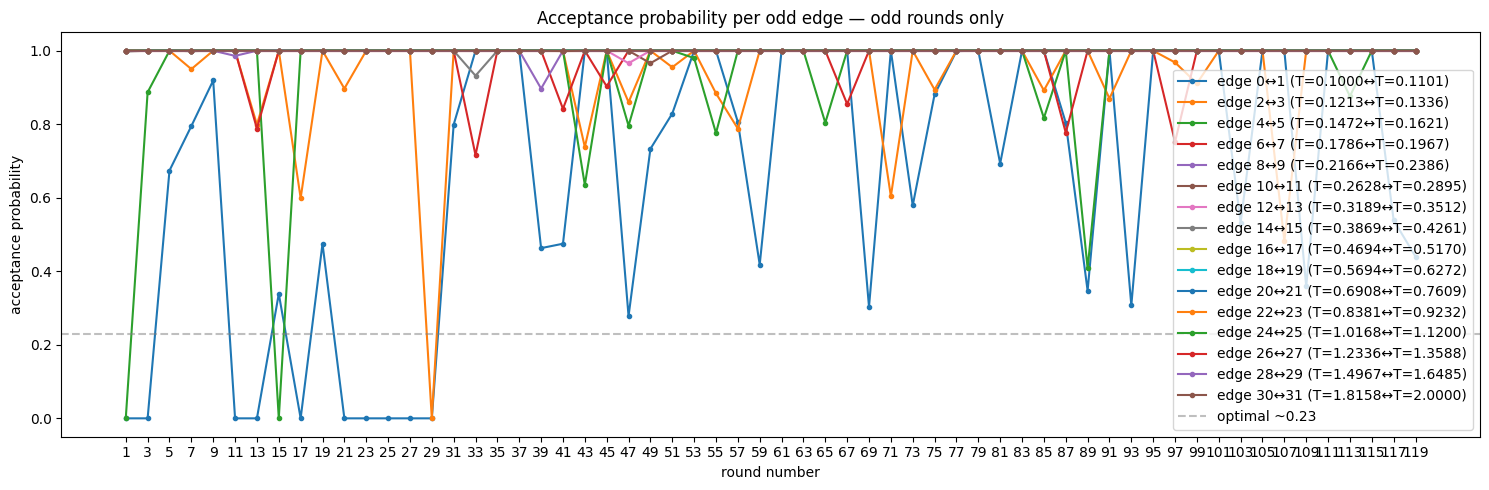

In [49]:
fig, ax = plt.subplots(figsize=(15, 5))

for b in range(0, n_bins - 1, 2):
    ax.plot(
        df_exp_stats.loc[odd_round_true_or_false, 'round_nbr'],
        probs_by_bin[odd_round_true_or_false, b],
        label=f'edge {b}↔{b+1} (T={temps[b]:.4f}↔T={temps[b+1]:.4f})',
        marker='o', markersize=3
    )

ax.set_xlabel('round number')
ax.set_xticks(df_exp_stats.loc[odd_round_true_or_false, 'round_nbr'])
ax.set_ylabel('acceptance probability')
ax.set_title('Acceptance probability per odd edge — odd rounds only')
ax.axhline(0.23, color='gray', linestyle='--', alpha=0.5, label='optimal ~0.23')
ax.legend()

plt.tight_layout()
fig.savefig('acceptance_prob_odd_edges.png', dpi=150, bbox_inches='tight')
plt.show()

The following plots the energy and probablity distributions between rounds, ideally the top temperature accepts $\approx 80\%$ of energy increasing deformations and the lowest temperature about $\approx 20\%$.

(This is just a heuristic guess Rhoslyn you need to check the literature for some ball park estimates.)

In [50]:
df_exp_stats_intra_rounds[:5:]

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round
0,1,1,0,0,0.1,1.000,0.00000,1,0.00000,0,0.000306,0,0
1,2,2,0,2020,0.1,0.998,0.00021,0,-0.00850,0,25.839197,0,2020
2,3,3,0,6063,0.1,1.062,-0.00604,0,-0.00732,0,79.904376,0,6063
3,4,4,0,7077,0.1,1.011,-0.00109,0,-0.01639,0,93.504922,0,7077
4,5,5,0,10120,0.1,0.956,0.00450,0,-0.00878,0,135.769553,0,10120


In [51]:
energy_increasing = df_exp_stats_intra_rounds[df_exp_stats_intra_rounds['deltaE'] > 0]

In [52]:
def suggest_drag_factor(df, bin_index=0):
    counts = (df[df['bin_index'] == bin_index]
              .groupby('round_nbr')
              .size())
    return int(counts.min() / 2)

dragfactor = suggest_drag_factor(df_exp_stats_intra_rounds)
print(f"Suggested drag factor: {dragfactor}")


Suggested drag factor: 59


In [53]:
dragfactor = 50

energy_increasing = energy_increasing.sort_values(['rank', 'it_no']) #sorts by rank and then it_no

# groupby('rank') splits the dataframe into groups, one per rank
# .apply(func) then applies func to each group independently
# rolling(window=3000) is a built-in pandas method
# for each row it looks back at the previous 3000 rows and computes the mean
# min_periods=1 means if there are fewer than 3000 rows available
# (e.g. at the start) it averages over however many are available


energy_increasing['exp(P)'] = energy_increasing.groupby('rank')['prob'].transform(lambda x: x.rolling(window=dragfactor, min_periods=1).mean())
energy_increasing['exp(delE)'] = energy_increasing.groupby('rank')['deltaE'].transform(lambda x: x.rolling(window=dragfactor, min_periods=1).mean())



In [54]:
energy_increasing[::20].head()

,id,curveID,rank,it_no,T,prob,deltaE,accept,energy,bin_index,time,round_nbr,it_no_intra_round,exp(P),exp(delE)
1,2,2,0,2020,0.1,0.998,0.00021,0,-0.00850,0,25.839197,0,2020,0.998000,0.000210
48,49,49,0,83136,0.1,0.970,0.00305,0,-0.00904,0,1123.522330,0,83136,0.938857,0.006619
83,84,84,0,161612,0.1,0.000,1.68621,0,-5.36213,0,2237.149141,0,161612,0.848561,0.158870
109,110,110,0,216338,0.1,0.000,3.94681,0,-7.57616,0,3645.049274,0,216338,0.585620,0.655767
133,134,134,0,267450,0.1,0.000,0.76870,0,-7.61426,0,5183.067576,0,267450,0.246760,1.249744


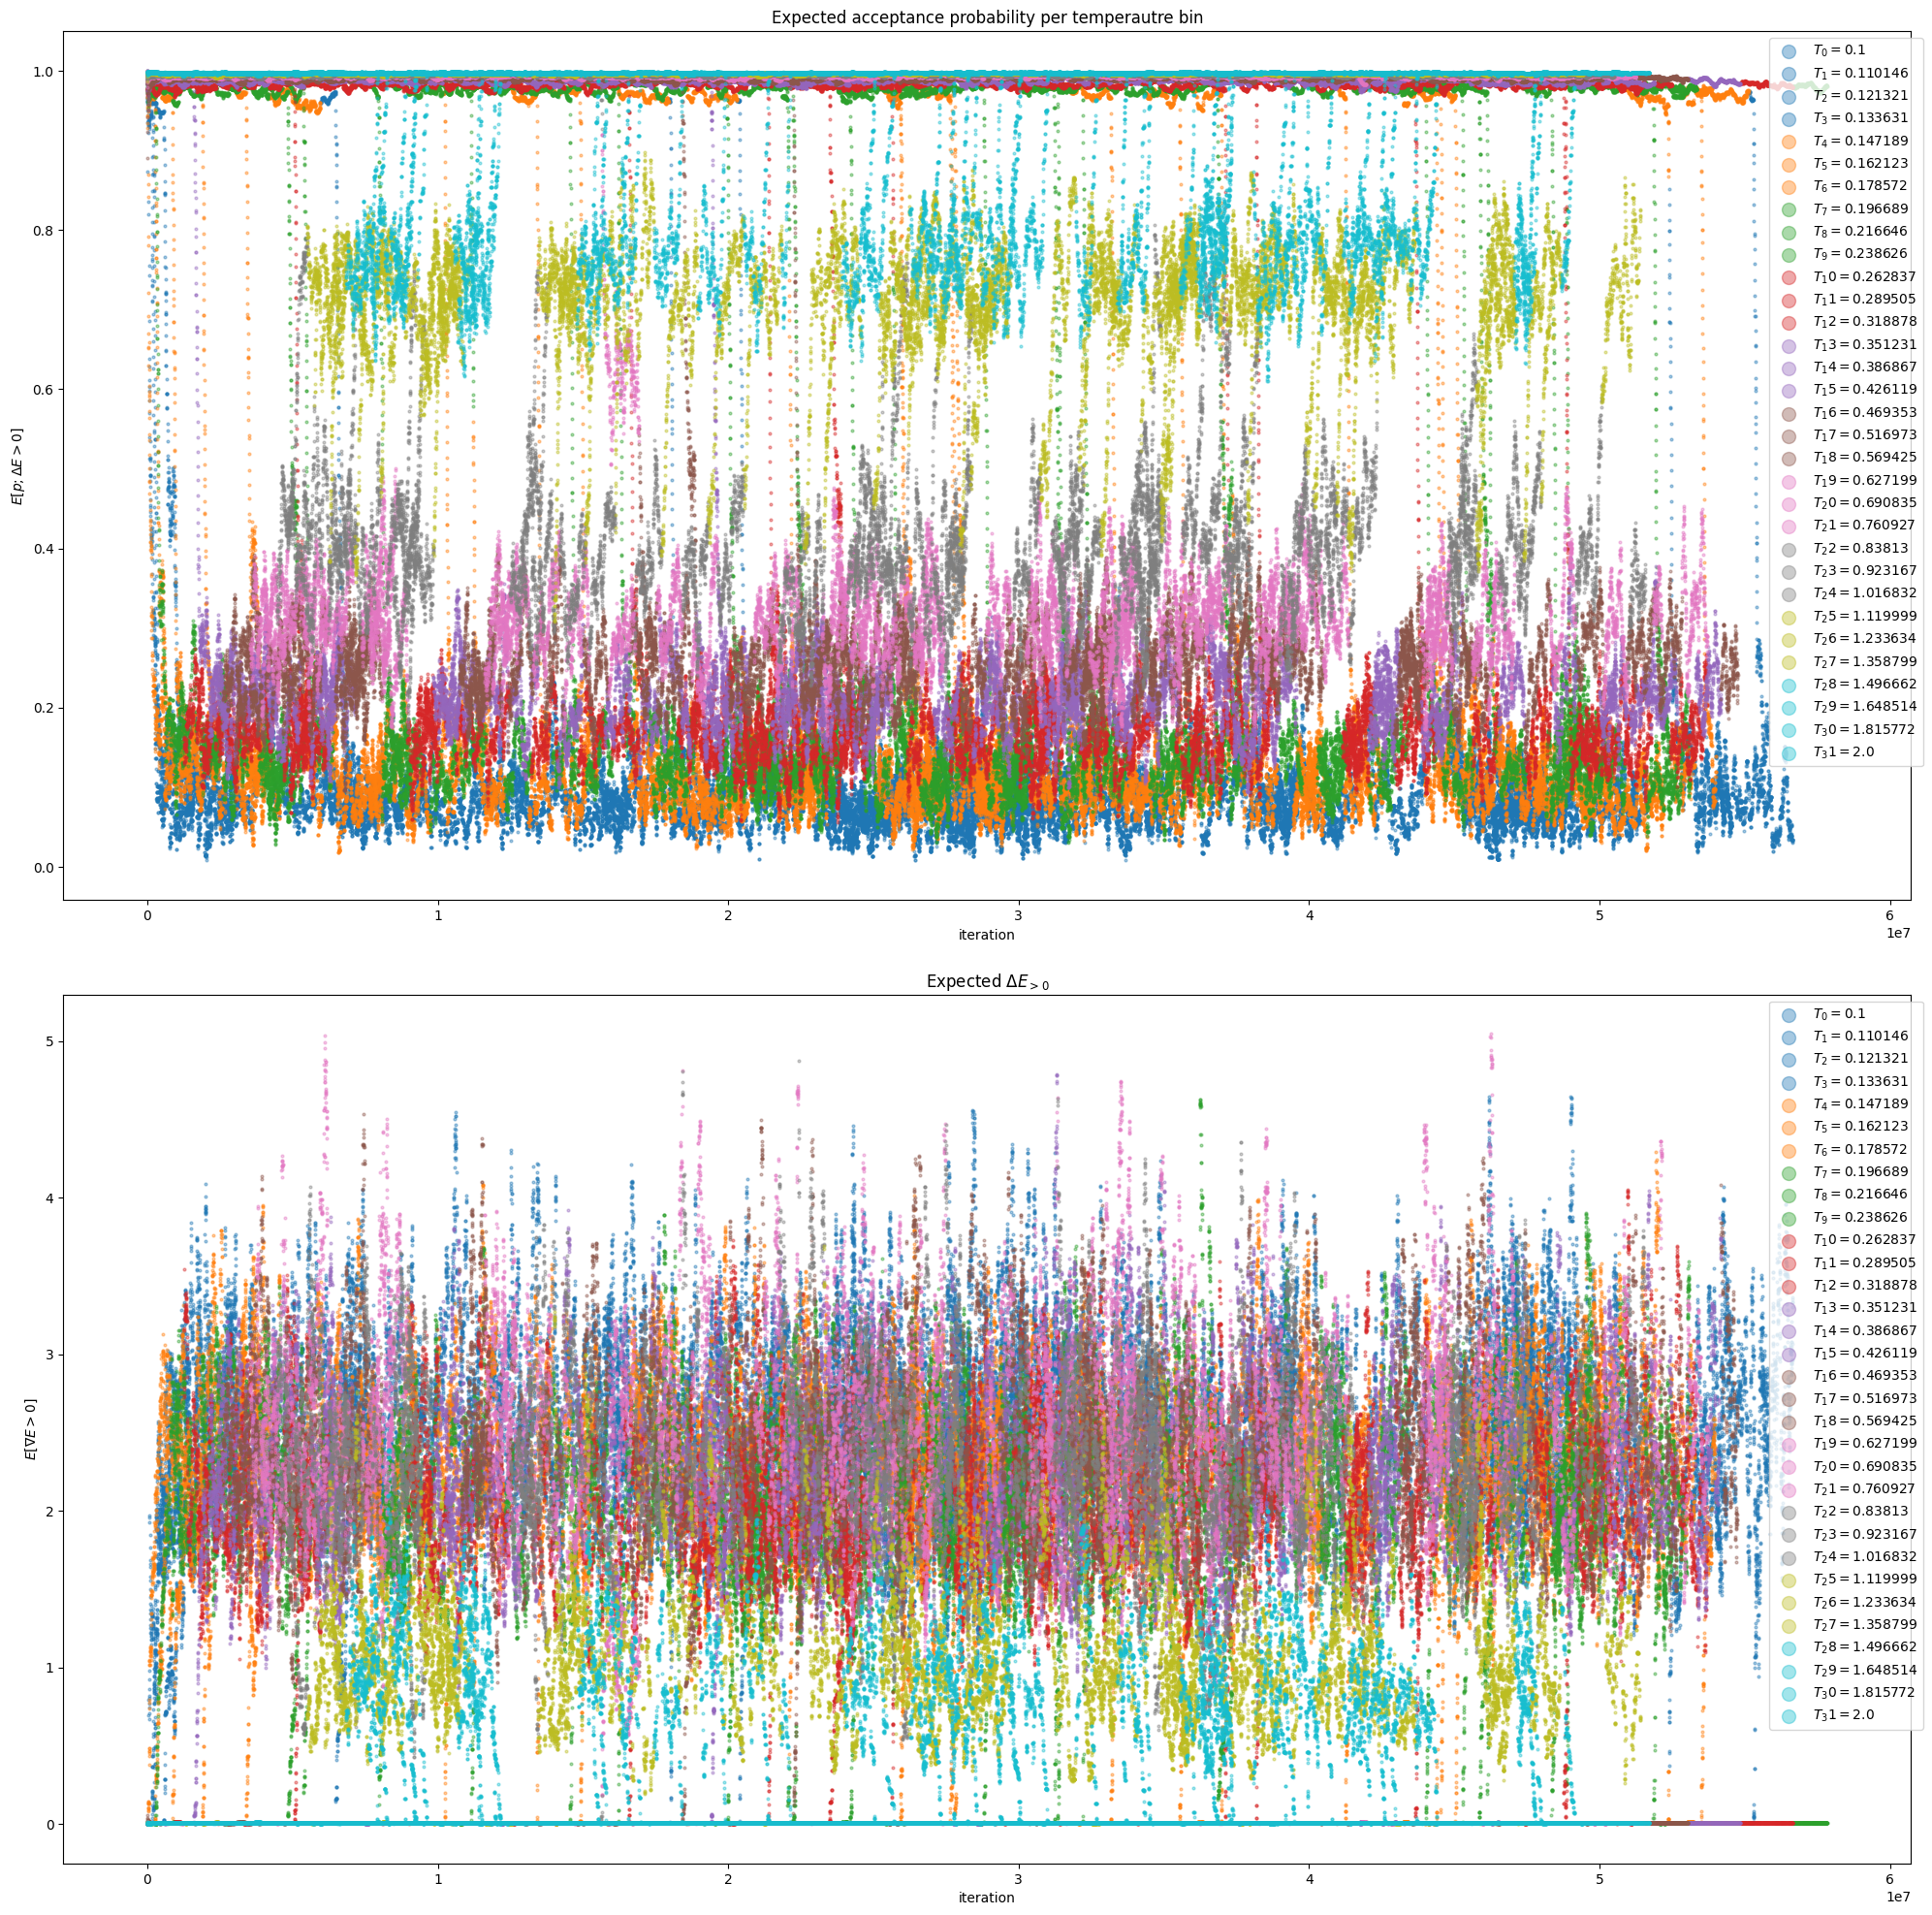

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(20, 20))

cmap = plt.get_cmap('tab10', size)

for b in range(size):
    bin_data = energy_increasing[energy_increasing['bin_index'] == b]
    
    axes[0].scatter(bin_data['it_no'], bin_data['exp(P)'], s=4,
                 color=cmap(b), label=rf'$T_{b}={temp_of_bin(b)}$', alpha=0.4)
    
    axes[1].scatter(bin_data['it_no'], bin_data['exp(delE)'],s=4,
                 color=cmap(b), label=rf'$T_{b}={temp_of_bin(b)}$', alpha=0.4)

axes[0].set_xlabel('iteration')
axes[0].set_ylabel(r'$E[p; \Delta E>0]$')
axes[0].set_title('Expected acceptance probability per temperautre bin')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper right', markerscale=5)

axes[1].set_xlabel('iteration')
axes[1].set_ylabel(r'$E[\nabla E >0]$')
axes[1].set_title(r'Expected $\Delta E_{>0}$')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper right',  markerscale=5)

plt.tight_layout()
fig.savefig('intra_round_rolling_averages_per_bin_index.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
def return_temp_for_expected_acceptance(deltaE, acceptance_prob):
    return -deltaE/np.log(acceptance_prob)

In [57]:
def avg_deltaE_well(df, n_bins, fraction_bins=0.25, fraction_rounds=0.5):
    max_round = df['round_nbr'].max()
    min_bin = int(n_bins * fraction_bins)
    return (df[
        (df['round_nbr'] >= max_round * fraction_rounds) &
        (df['bin_index'] < min_bin) &
        (df['deltaE'] > 0)
    ]['deltaE'].mean())

print(avg_deltaE_well(df_exp_stats_intra_rounds, size))

2.2244595280969675


In [58]:
T_p_middle = return_temp_for_expected_acceptance(avg_deltaE_well(df_exp_stats_intra_rounds, size), 0.2) #midrange temp

In [59]:
T_p_bot = return_temp_for_expected_acceptance(avg_deltaE_well(df_exp_stats_intra_rounds, size), 0.08) 

In [60]:
def return_temp_range_for_mid_temp_geometric(T_bot, T_mid, size): #I don't think this is particularly helpful
    n = size
    return (T_bot, T_bot*pow(T_mid/T_bot, 2*(n-1)/n))

In [61]:
return_temp_range_for_mid_temp_geometric(T_p_bot, T_p_middle, 12)


(0.8807199194219855, 2.0120742333814423)

In [62]:
conn.close()